# YOLO26 Fine-Tuning - Football Players Detection

Fine-tuning **YOLO26** on the Roboflow dataset
[`football-player-detection-5hh8o`](https://universe.roboflow.com/image-recognition-cxqjc/football-player-detection-5hh8o/dataset/1)
(classes: `ball`, `goalkeeper`, `player`, `referee`).

**Pipeline:** environment check -> dataset download -> training -> evaluation (metrics + saved plots) -> inference sanity check -> export weights for reuse in the rest of the project.

**Runs on either Google Colab or Kaggle** - Section 1 auto-detects the platform and adjusts paths accordingly.


In [11]:
# Detect platform (Colab vs Kaggle vs local) so paths behave correctly either way
import os

IN_COLAB = "COLAB_GPU" in os.environ or "google.colab" in str(get_ipython())
IN_KAGGLE = "KAGGLE_KERNEL_RUN_TYPE" in os.environ

if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    PLATFORM = "colab"
    WORK_DIR = "/content"
elif IN_KAGGLE:
    PLATFORM = "kaggle"
    WORK_DIR = "/kaggle/working"
else:
    PLATFORM = "local"
    WORK_DIR = os.getcwd()

os.makedirs(WORK_DIR, exist_ok=True)
os.chdir(WORK_DIR)
print(f"Detected platform: {PLATFORM}")
print(f"Working directory: {WORK_DIR}")


Detected platform: kaggle
Working directory: /kaggle/working


In [12]:
# GPU check - make sure a GPU runtime/accelerator is actually attached before training
!nvidia-smi


Wed Sep 30 07:06:19 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.159.04             Driver Version: 580.159.04     CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   40C    P8             10W /   70W |       3MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [13]:
%pip install -q ultralytics roboflow supervision

import ultralytics
ultralytics.checks()


Ultralytics 8.4.166 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
Setup complete ✅ (4 CPUs, 31.3 GB RAM, 7037.9/8156.9 GB disk)


## 2. Download the dataset from Roboflow

You need a free Roboflow account and API key (Roboflow dashboard -> Settings -> API Keys).
The cell below prompts for it via `getpass` so the key never gets saved in the notebook / pushed to any repo.

Set `DATASET_VERSION` to the version number you want (check the "Versions" tab on the
[dataset page](https://universe.roboflow.com/roboflow-jvuqo/football-players-detection-3zvbc) -
version `1` is the original 372-image release; later versions have more data/augmentation).


In [14]:
from getpass import getpass
from roboflow import Roboflow

ROBOFLOW_API_KEY = getpass("Enter your Roboflow API key: ")

DATASET_WORKSPACE = "image-recognition-cxqjc"
DATASET_PROJECT = "football-player-detection-5hh8o"
DATASET_VERSION = 1  # change if you want a different dataset version

rf = Roboflow(api_key=ROBOFLOW_API_KEY)
project = rf.workspace(DATASET_WORKSPACE).project(DATASET_PROJECT)
version = project.version(DATASET_VERSION)

# YOLO26 export format also matches YOLO11 dir layout (Ultralytics YOLO format is shared)
dataset = version.download("yolo26")

DATASET_DIR = dataset.location
print(f"Dataset downloaded to: {DATASET_DIR}")


Enter your Roboflow API key:  ········


loading Roboflow workspace...
loading Roboflow project...
Dataset downloaded to: /kaggle/working/Football-Player-Detection-1


In [15]:
# Inspect data.yaml and confirm the classes match what we expect (ball, goalkeeper, player, referee)
import yaml

data_yaml_path = os.path.join(DATASET_DIR, "data.yaml")
with open(data_yaml_path) as f:
    data_cfg = yaml.safe_load(f)

print(yaml.dump(data_cfg, sort_keys=False))


train: /kaggle/working/Football-Player-Detection-1/train/images
val: /kaggle/working/Football-Player-Detection-1/valid/images
test: /kaggle/working/Football-Player-Detection-1/test/images
nc: 4
names:
- ball
- goalkeeper
- player
- referee
roboflow:
  workspace: image-recognition-cxqjc
  project: football-player-detection-5hh8o
  version: 1
  license: CC BY 4.0
  url: https://universe.roboflow.com/image-recognition-cxqjc/football-player-detection-5hh8o/dataset/1



In [16]:
# Roboflow's default data.yaml uses relative train/valid/test paths meant for its own CLI.
# Rewrite them as absolute paths (and normalize "valid" -> "val") so Ultralytics finds the
# images regardless of current working directory.
val_key = "valid" if "valid" in data_cfg else "val"

for split_key, yaml_key in (("train", "train"), ("val", val_key), ("test", "test")):
    if yaml_key in data_cfg:
        rel = data_cfg[yaml_key]
        abs_path = os.path.normpath(os.path.join(DATASET_DIR, rel))
        data_cfg[split_key] = abs_path

# drop the now-redundant "valid" key once its value has been copied to "val"
if val_key == "valid":
    data_cfg.pop("valid", None)

with open(data_yaml_path, "w") as f:
    yaml.dump(data_cfg, f, sort_keys=False)

print(yaml.dump(data_cfg, sort_keys=False))


train: /kaggle/working/Football-Player-Detection-1/train/images
val: /kaggle/working/Football-Player-Detection-1/valid/images
test: /kaggle/working/Football-Player-Detection-1/test/images
nc: 4
names:
- ball
- goalkeeper
- player
- referee
roboflow:
  workspace: image-recognition-cxqjc
  project: football-player-detection-5hh8o
  version: 1
  license: CC BY 4.0
  url: https://universe.roboflow.com/image-recognition-cxqjc/football-player-detection-5hh8o/dataset/1



In [17]:
print("DATASET_DIR:", DATASET_DIR)
for root, dirs, files in os.walk(DATASET_DIR):
    level = root.replace(DATASET_DIR, "").count(os.sep)
    print("  " * level + os.path.basename(root) + "/")
    for f in files[:3]:
        print("  " * (level + 1) + f)

DATASET_DIR: /kaggle/working/Football-Player-Detection-1
Football-Player-Detection-1/
  README.roboflow.txt
  README.dataset.txt
  data.yaml
  train/
    labels/
      744b27_3_1_png_jpg.rf.49dff8b45cb15a997eb1db9a792d998b.txt
      121364_9_7_png_jpg.rf.6029acf850a00f17191ee18e2e79b83f.txt
      a9f16c_8_2_png_jpg.rf.d704d915d3d3f713cea5c17d0efb9607.txt
    images/
      573e61_3_9_png_jpg.rf.7a4f3c46b1178c12cee164b722f26115.jpg
      08fd33_6_7_png_jpg.rf.02616631c607b350dec980349de174e8.jpg
      538438_1_5_png_jpg.rf.5af16587fa2944fc20b861a077b845f4.jpg
  valid/
    labels/
      744b27_3_6_png_jpg.rf.89a3ea93456bb12e1fe1409f3623aa2c.txt
      798b45_3_7_png_jpg.rf.cd57772ecfd658c376f2e05533d44746.txt
      08fd33_0_3_png_jpg.rf.19d1db9cb7ca94c5de76b433a2b2173f.txt
    images/
      42ba34_5_6_png_jpg.rf.2889c875a9a74c9a8efb55128ec1057d.jpg
      2e57b9_3_8_png_jpg.rf.e226c57d7f2f33c500455bd8ae83b4b3.jpg
      798b45_3_4_png_jpg.rf.c70af4aceb29461e6bb152b77d73081f.jpg
  test/
    l

In [18]:
import glob

for split_key, folder_name in (("train", "train"), ("val", "valid"), ("test", "test")):
    candidate = os.path.join(DATASET_DIR, folder_name, "images")
    if os.path.isdir(candidate):
        data_cfg[split_key] = candidate

data_cfg.pop("valid", None)

with open(data_yaml_path, "w") as f:
    yaml.dump(data_cfg, f, sort_keys=False)

print(yaml.dump(data_cfg, sort_keys=False))

for split_key in ("train", "val"):
    n = len(glob.glob(os.path.join(data_cfg[split_key], "*.jpg")))
    print(f"{split_key}: {n} images found at {data_cfg[split_key]}")
    assert n > 0, f"Still no images for '{split_key}' - check folder layout"

train: /kaggle/working/Football-Player-Detection-1/train/images
val: /kaggle/working/Football-Player-Detection-1/valid/images
test: /kaggle/working/Football-Player-Detection-1/test/images
nc: 4
names:
- ball
- goalkeeper
- player
- referee
roboflow:
  workspace: image-recognition-cxqjc
  project: football-player-detection-5hh8o
  version: 1
  license: CC BY 4.0
  url: https://universe.roboflow.com/image-recognition-cxqjc/football-player-detection-5hh8o/dataset/1

train: 771 images found at /kaggle/working/Football-Player-Detection-1/train/images
val: 73 images found at /kaggle/working/Football-Player-Detection-1/valid/images


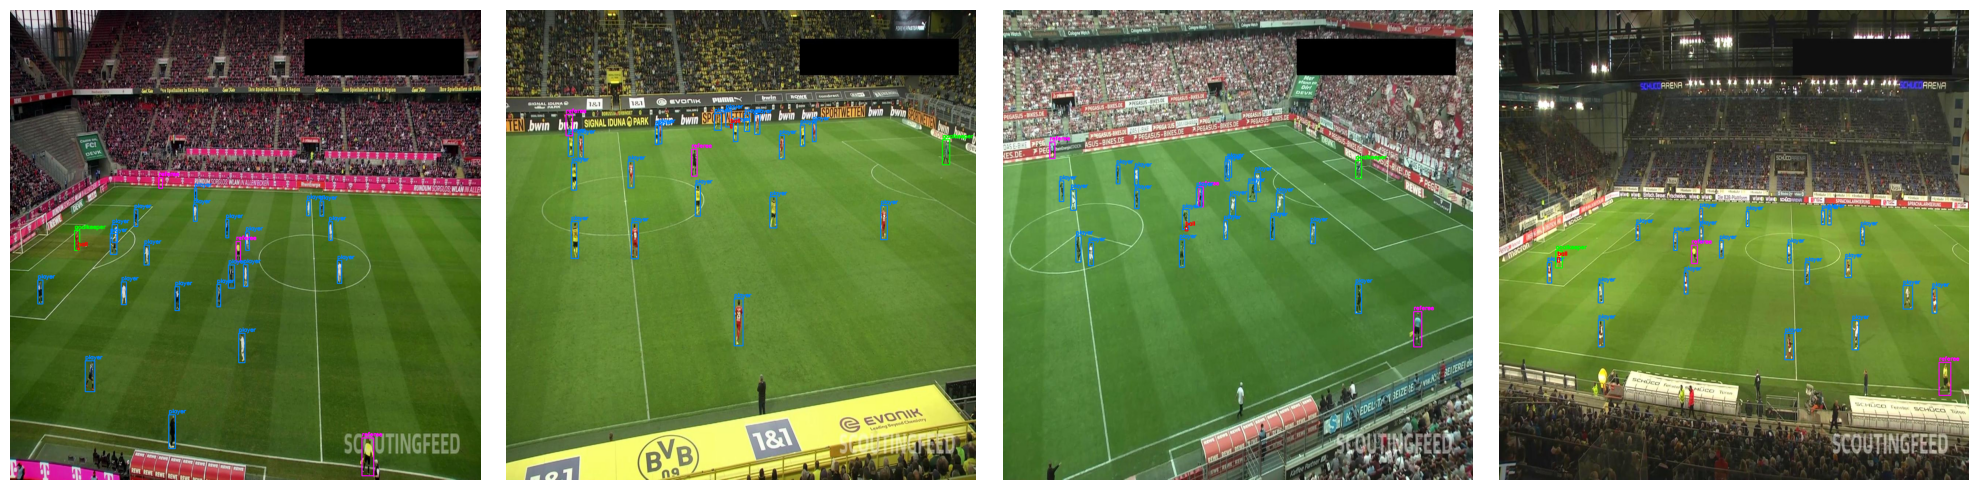

In [19]:
# Quick visual sanity check: plot a few training images with their ground-truth boxes
import glob
import random
import cv2
import matplotlib.pyplot as plt

CLASS_NAMES = data_cfg["names"]
CLASS_COLORS = [(255, 0, 0), (0, 255, 0), (0, 128, 255), (255, 0, 255)]

train_img_dir = data_cfg["train"]
train_lbl_dir = train_img_dir.replace("images", "labels")

all_imgs = glob.glob(os.path.join(train_img_dir, "*.jpg"))
assert len(all_imgs) > 0, f"No images found in {train_img_dir}"

sample_imgs = random.sample(all_imgs, k=min(4, len(all_imgs)))

fig, axes = plt.subplots(1, len(sample_imgs), figsize=(5 * len(sample_imgs), 5))
if len(sample_imgs) == 1:
    axes = [axes]

for ax, img_path in zip(axes, sample_imgs):
    img = cv2.cvtColor(cv2.imread(img_path), cv2.COLOR_BGR2RGB)
    h, w = img.shape[:2]
    lbl_path = os.path.join(train_lbl_dir, os.path.basename(img_path).replace(".jpg", ".txt"))
    if os.path.exists(lbl_path):
        with open(lbl_path) as f:
            for line in f:
                cls, xc, yc, bw, bh = map(float, line.split())
                x1, y1 = int((xc - bw / 2) * w), int((yc - bh / 2) * h)
                x2, y2 = int((xc + bw / 2) * w), int((yc + bh / 2) * h)
                color = CLASS_COLORS[int(cls) % len(CLASS_COLORS)]
                cv2.rectangle(img, (x1, y1), (x2, y2), color, 2)
                cv2.putText(img, CLASS_NAMES[int(cls)], (x1, max(y1 - 5, 0)),
                            cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 2)
    ax.imshow(img)
    ax.axis("off")
plt.tight_layout()
plt.show()

## 3. Train YOLO26

Notes on the hyperparameters below:
- **`imgsz=1280`**: higher than the YOLO default (640) because the `ball` class is tiny relative to the frame - low resolution tanks recall on it specifically. Drop to 960/640 if you hit GPU memory limits.
- **`batch=-1`**: Ultralytics auto-picks the largest batch size that fits in GPU memory (~60% util target). Set a fixed number (e.g. 8 or 16) if autobatch misbehaves.
- **`patience=20`**: early stopping if `mAP50-95` doesn't improve for 20 epochs, so you don't waste GPU quota on a plateaued run.
- **`yolo26s`** is a good accuracy/speed tradeoff for a thesis project; swap to `yolo26m.pt` if you want higher accuracy and have GPU-hours to spare, or `yolo26n.pt` for fastest iteration while debugging the pipeline.


In [20]:
from ultralytics import YOLO

MODEL_SIZE = "yolo26m.pt"
EPOCHS = 150
IMG_SIZE = 1280
PATIENCE = 20
RUN_NAME = "football_players_yolo26m"
BATCH_SIZE = 8

model = YOLO(MODEL_SIZE)

results = model.train(
    data=data_yaml_path,
    epochs=EPOCHS,
    imgsz=IMG_SIZE,
    batch=BATCH_SIZE,
    patience=PATIENCE,
    device=0,               # GPU 0; use "cpu" only for a smoke test, training on CPU is impractical here
    project=os.path.join(WORK_DIR, "runs_detect"),
    name=RUN_NAME,
    exist_ok=True,
    plots=True,             # makes ultralytics save confusion matrix / PR curves / etc. automatically
    val=True,
    seed=42,
)

RUN_DIR = os.path.join(WORK_DIR, "runs_detect", RUN_NAME)
print(f"Training run saved to: {RUN_DIR}")


Ultralytics 8.4.166 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/Football-Player-Detection-1/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=150, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=1280, iou=0.7, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26m.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=football_players_yolo26m, nbs=64, n

`get_trial_id` is meant to only be called inside a function that is executed by a Tuner or Trainer. Returning `None`.


      2/150      9.91G      1.028     0.8551     0.0011        103       1280: 100% ━━━━━━━━━━━━ 193/193 2.0it/s 1:370.5sss
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 10/10 2.5it/s 3.9s.4ss
                   all         73       1759      0.871      0.779      0.838       0.57

      Epoch    GPU_mem   box_loss   cls_loss    l1_loss  Instances       Size
      3/150      9.88G      1.101     0.6982   0.001258         62       1280: 100% ━━━━━━━━━━━━ 193/193 2.0it/s 1:370.5sss
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 10/10 2.6it/s 3.9s.4ss
                   all         73       1759      0.898      0.842      0.867      0.584

      Epoch    GPU_mem   box_loss   cls_loss    l1_loss  Instances       Size
      4/150      9.94G      1.052     0.6222   0.001223         84       1280: 100% ━━━━━━━━━━━━ 193/193 2.0it/s 1:370.5sss
                 Class     Ima

## 4. Evaluate the trained model

1. Run `model.val()` explicitly on the validation split to get a clean metrics object (mAP50, mAP50-95, precision, recall - overall and per-class).
2. Collect and display every evaluation plot Ultralytics generated during training/validation (confusion matrix, PR/F1/P/R curves, label distribution, predicted-vs-ground-truth batches) - these all get saved as image files for report.


In [21]:
# Explicit validation pass -> metrics object
metrics = model.val(
    data=data_yaml_path,
    imgsz=IMG_SIZE,
    split="val",
    project=os.path.join(WORK_DIR, "runs_detect"),
    name=RUN_NAME + "_eval",
    exist_ok=True,
    plots=True,
)

EVAL_DIR = os.path.join(WORK_DIR, "runs_detect", RUN_NAME + "_eval")
print(f"Evaluation artifacts saved to: {EVAL_DIR}")

print("\n--- Overall metrics ---")
print(f"mAP50:     {metrics.box.map50:.4f}")
print(f"mAP50-95:  {metrics.box.map:.4f}")
print(f"Precision: {metrics.box.mp:.4f}")
print(f"Recall:    {metrics.box.mr:.4f}")


Ultralytics 8.4.166 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
YOLO26m summary (fused): 130 layers, 20,352,536 parameters, 0 gradients, 68.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 3062.5±603.3 MB/s, size: 189.1 KB)
val: Scanning /kaggle/working/Football-Player-Detection-1/valid/labels.cache... 73 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 73/73 30.6Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 5/5 2.2s/it 11.1s3.2s
                   all         73       1759       0.94      0.883      0.887      0.642
                  ball         64         64      0.976      0.624      0.703      0.343
            goalkeeper         50         54      0.879      0.944      0.868      0.662
                player         73       1465      0.984      0.976      0.991       0.81
               referee         73        176      0.923      0.989      0.986      0.755
Speed: 17.3ms p

In [22]:
# Per-class AP50-95 table, saved as CSV for the thesis appendix
import pandas as pd

per_class_rows = []
for i, cls_name in CLASS_NAMES.items() if isinstance(CLASS_NAMES, dict) else enumerate(CLASS_NAMES):
    per_class_rows.append({
        "class": cls_name,
        "AP50-95": metrics.box.maps[i],
    })

per_class_df = pd.DataFrame(per_class_rows)
print(per_class_df.to_string(index=False))

metrics_csv_path = os.path.join(EVAL_DIR, "per_class_metrics.csv")
per_class_df.to_csv(metrics_csv_path, index=False)
print(f"\nSaved per-class metrics to {metrics_csv_path}")


     class  AP50-95
      ball 0.343186
goalkeeper 0.661673
    player 0.809849
   referee 0.754862

Saved per-class metrics to /kaggle/working/runs_detect/football_players_yolo26m_eval/per_class_metrics.csv


confusion_matrix.png


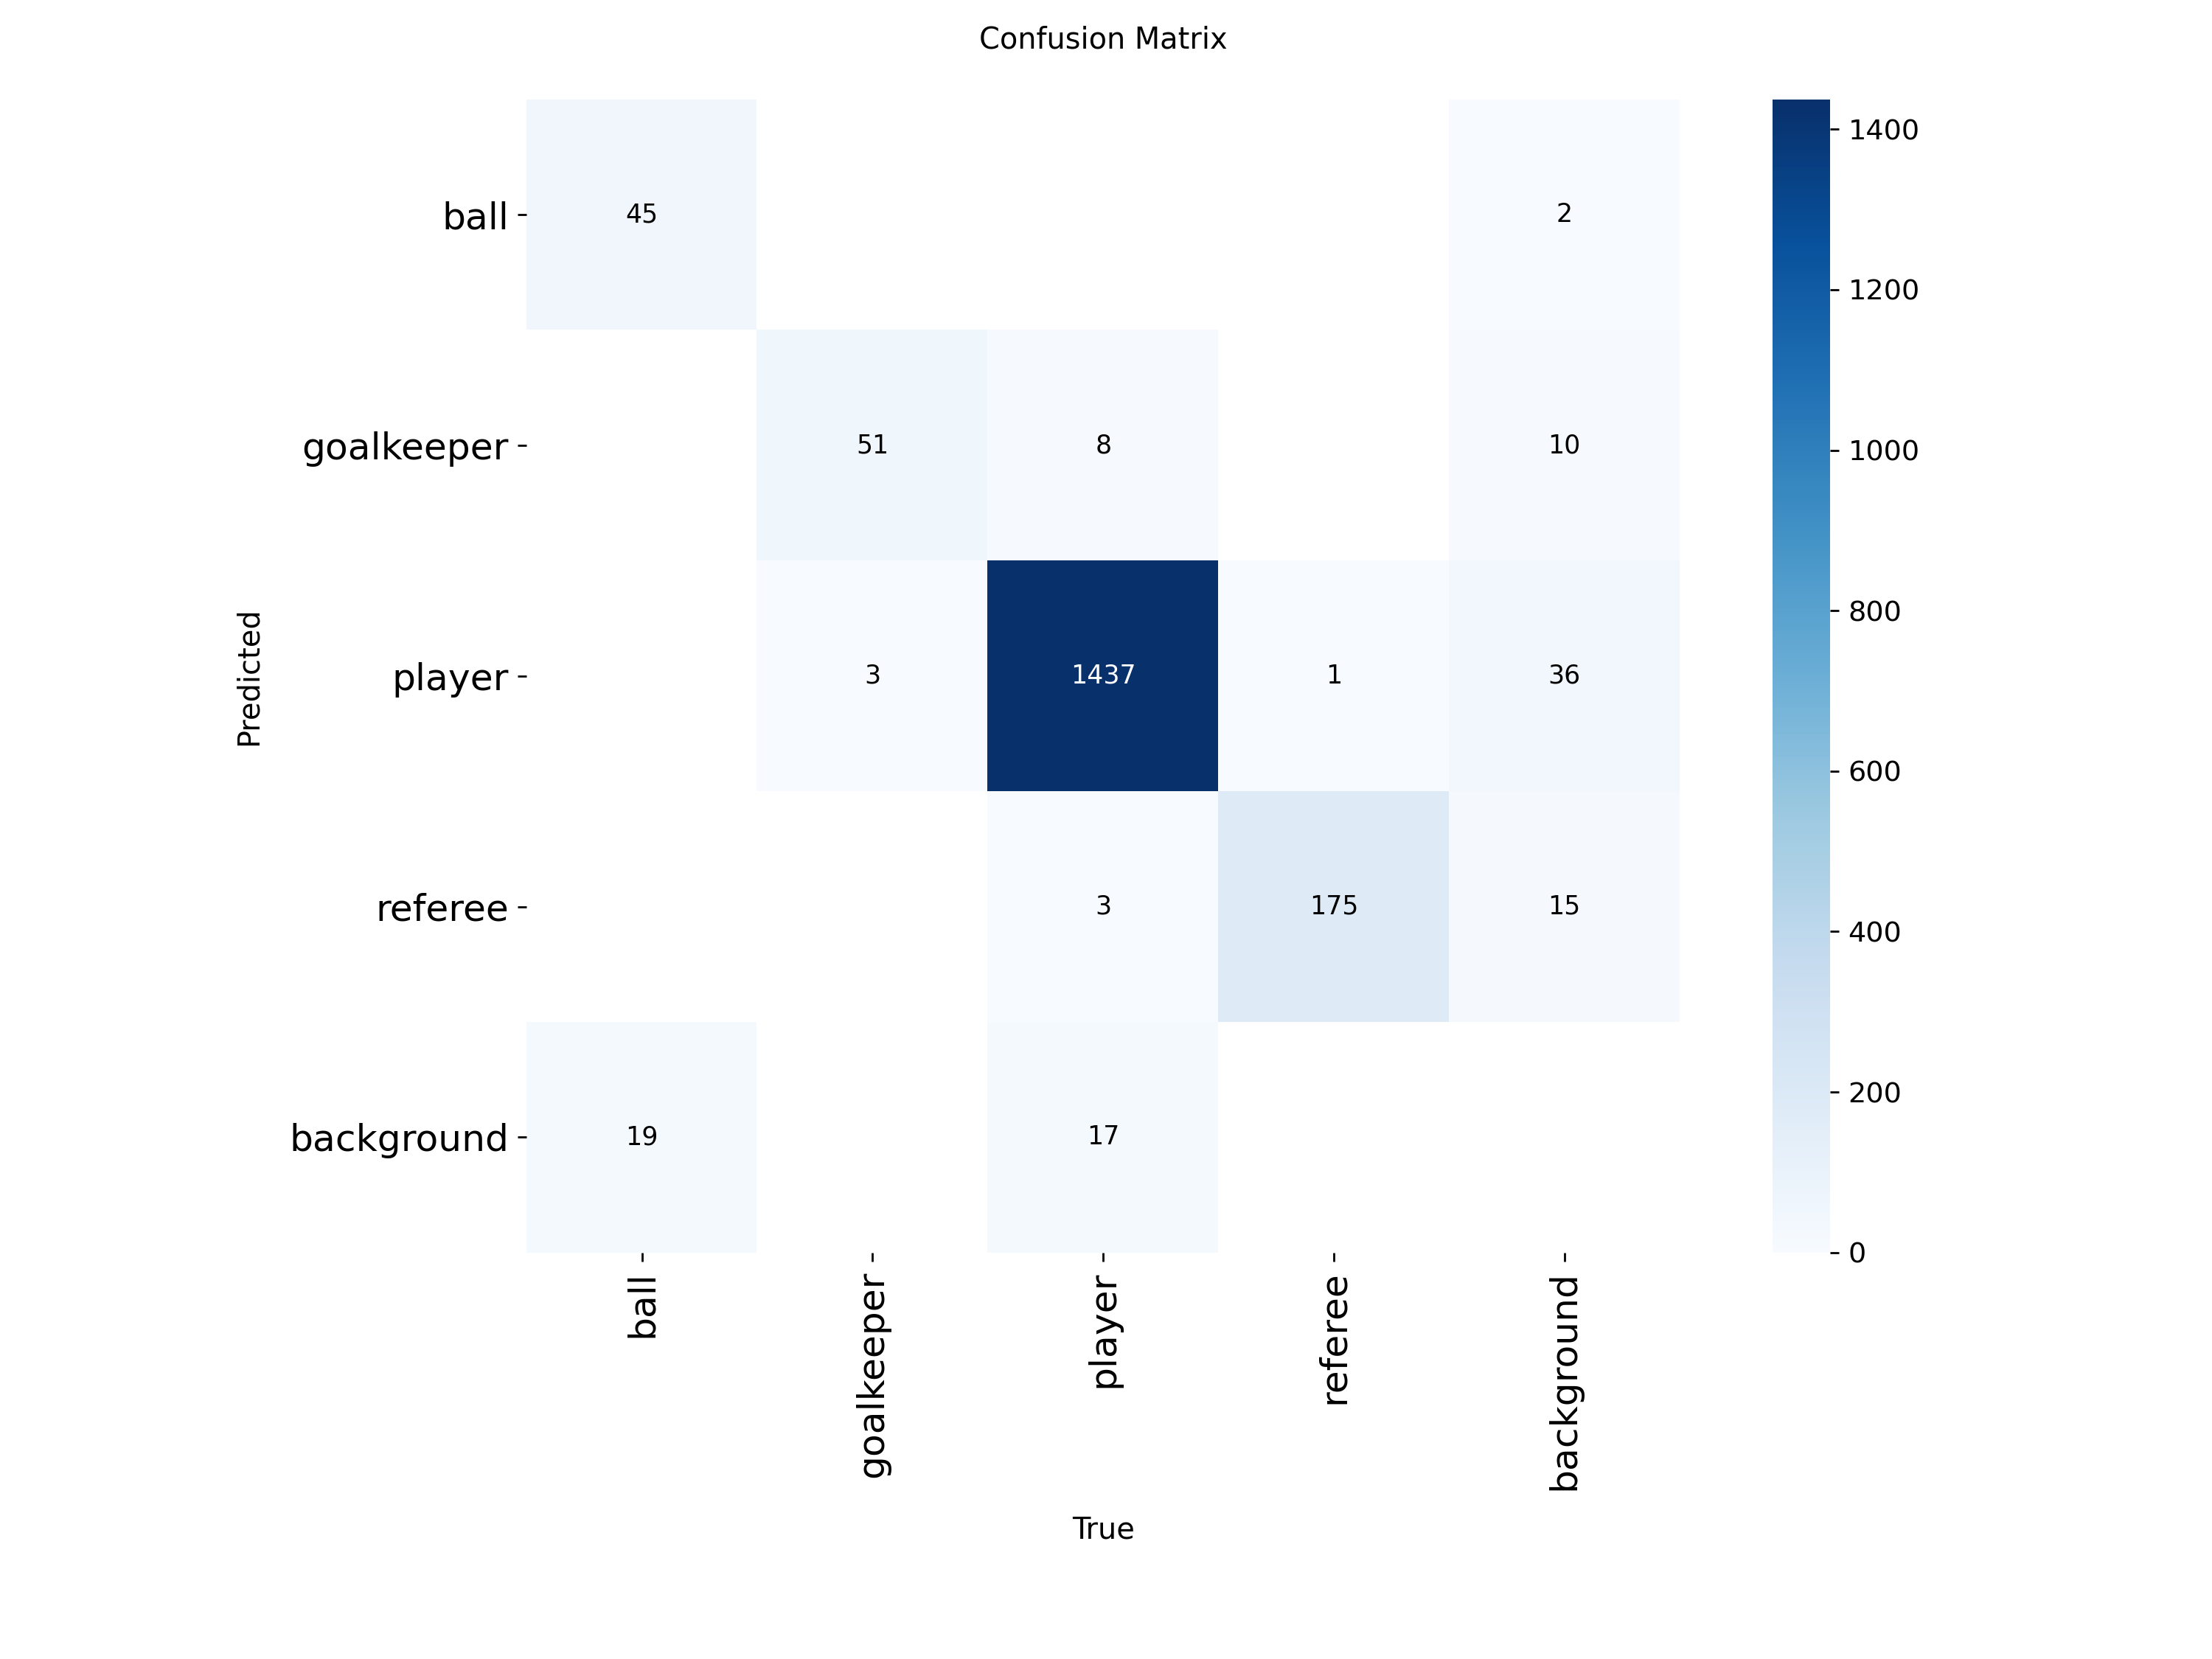

confusion_matrix_normalized.png


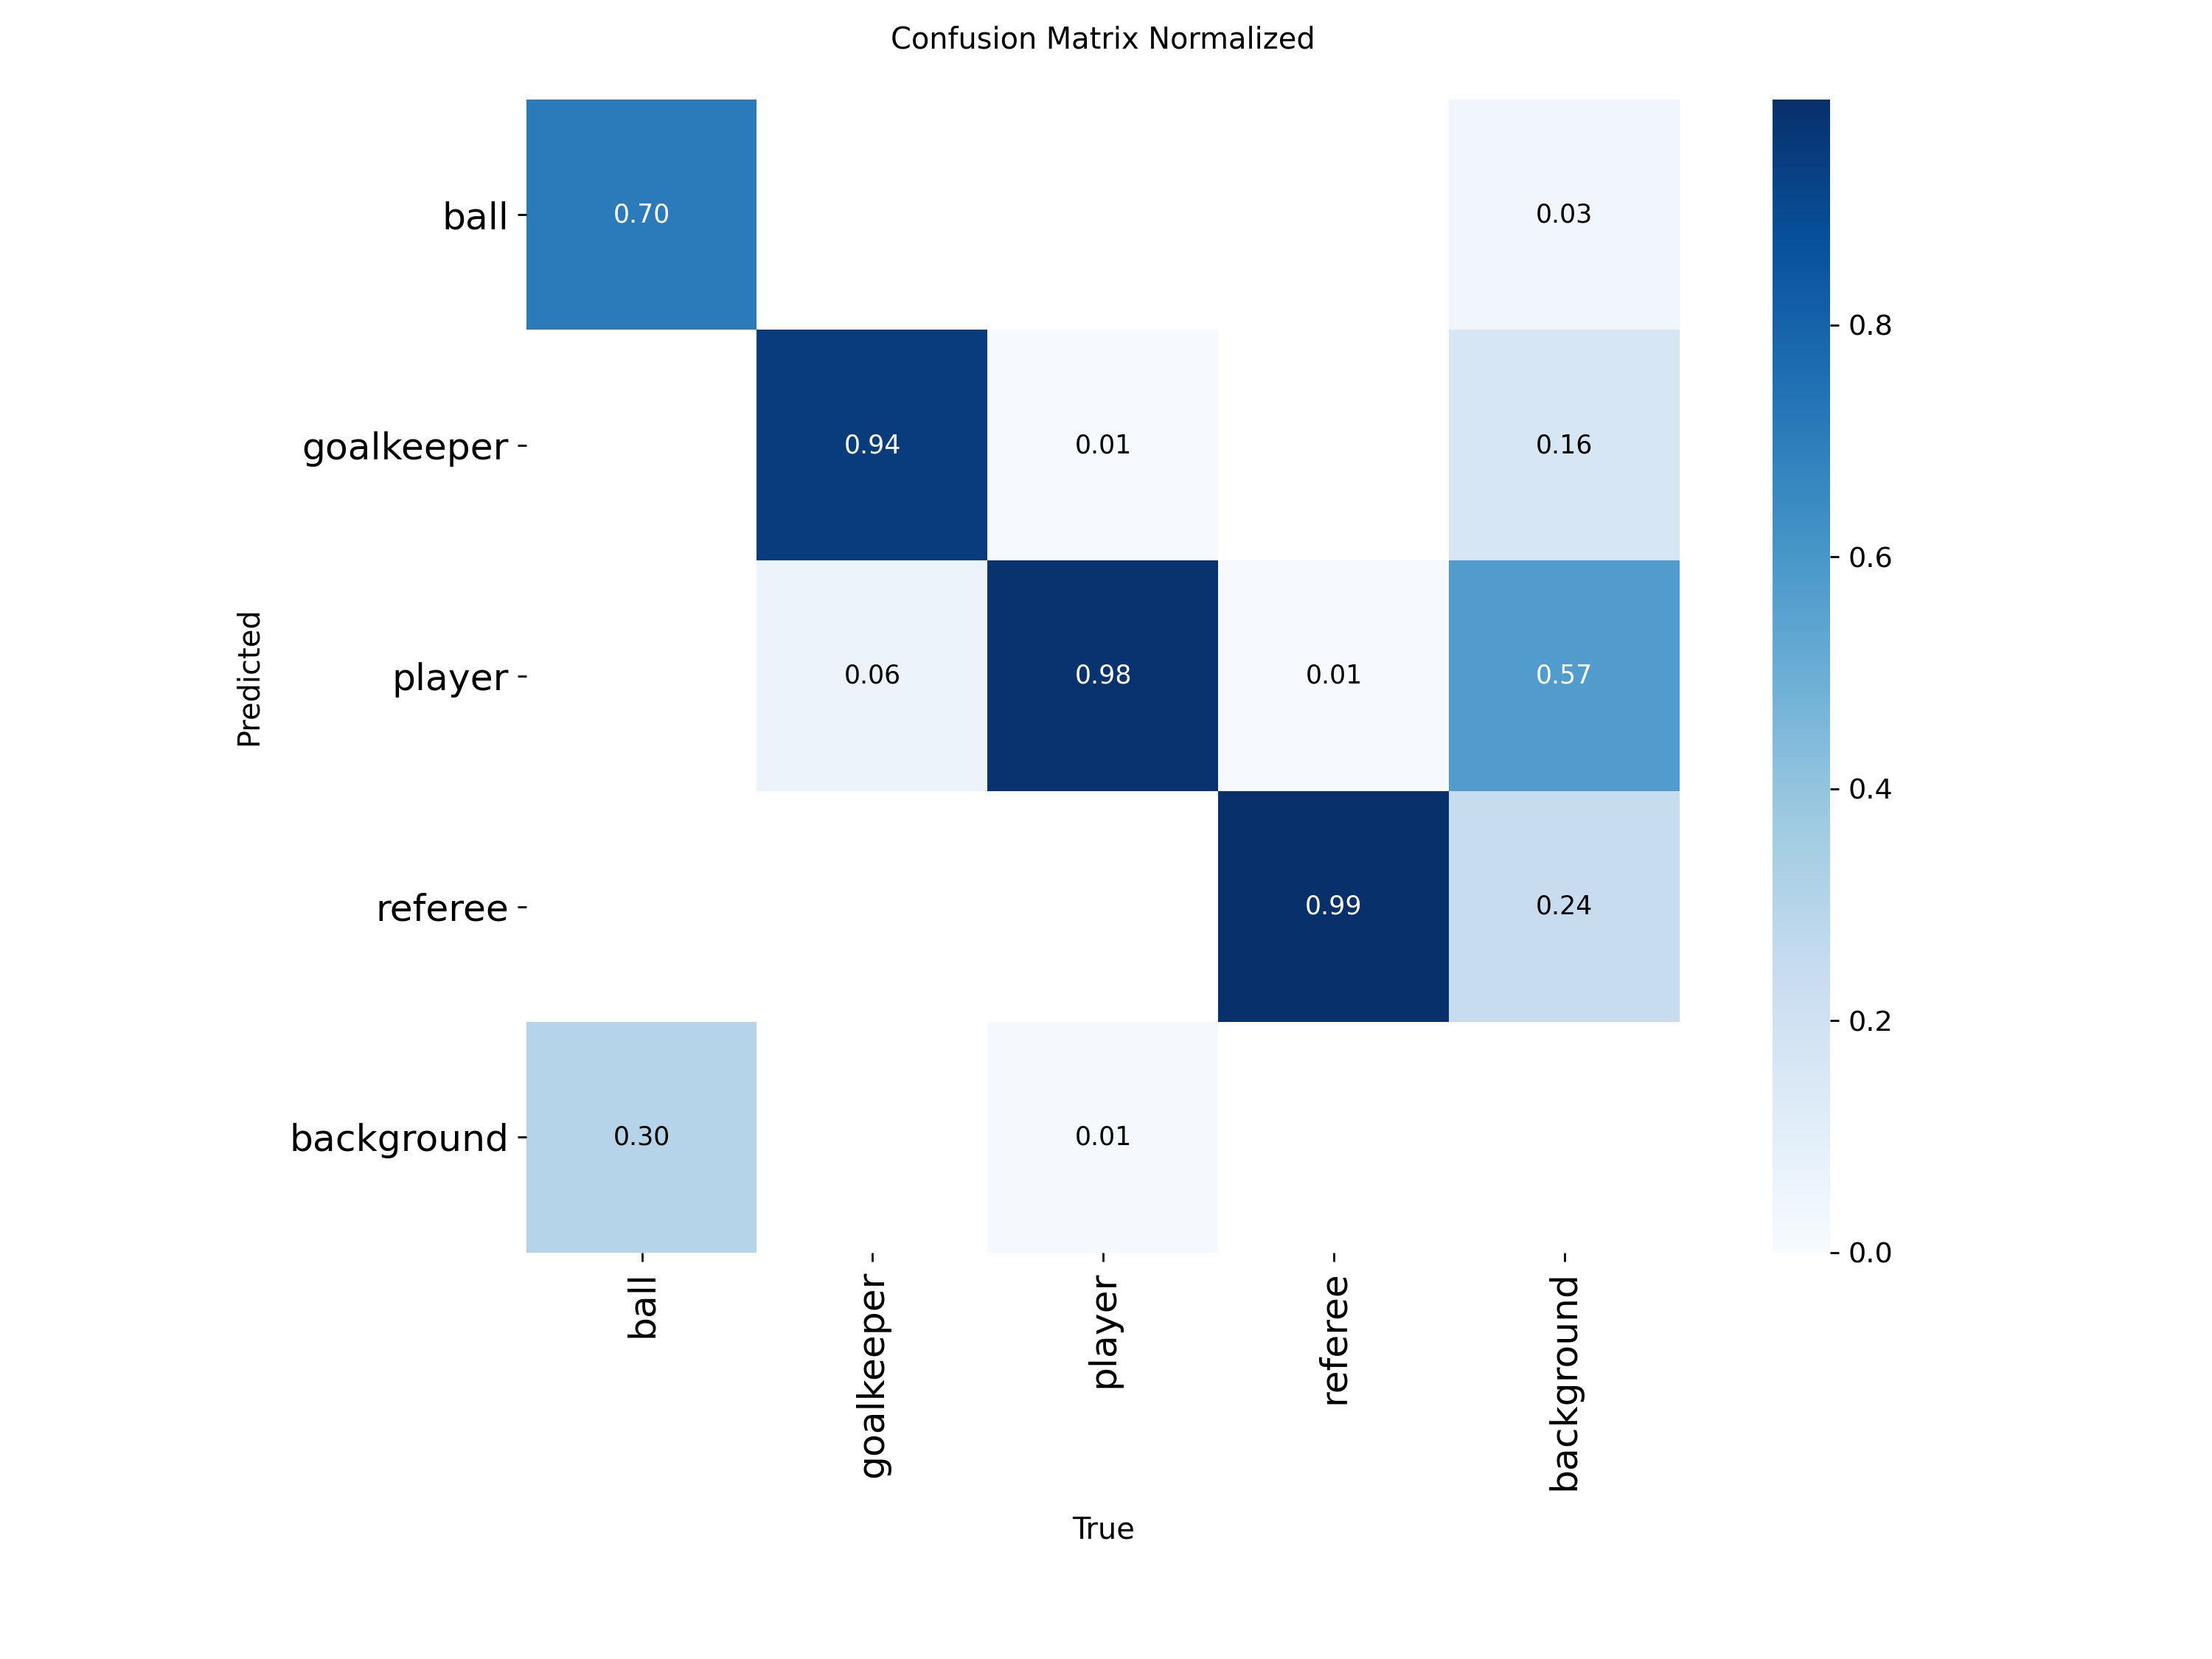

(not found: PR_curve.png)
(not found: F1_curve.png)
(not found: P_curve.png)
(not found: R_curve.png)


In [23]:
# Display the key evaluation plots inline (they're already saved as PNGs on disk by Ultralytics)
from IPython.display import Image as IPyImage, display

eval_plots = [
    "confusion_matrix.png",
    "confusion_matrix_normalized.png",
    "PR_curve.png",
    "F1_curve.png",
    "P_curve.png",
    "R_curve.png",
]

for plot_name in eval_plots:
    plot_path = os.path.join(EVAL_DIR, plot_name)
    if os.path.exists(plot_path):
        print(plot_name)
        display(IPyImage(filename=plot_path, width=700))
    else:
        print(f"(not found: {plot_name})")


results.png


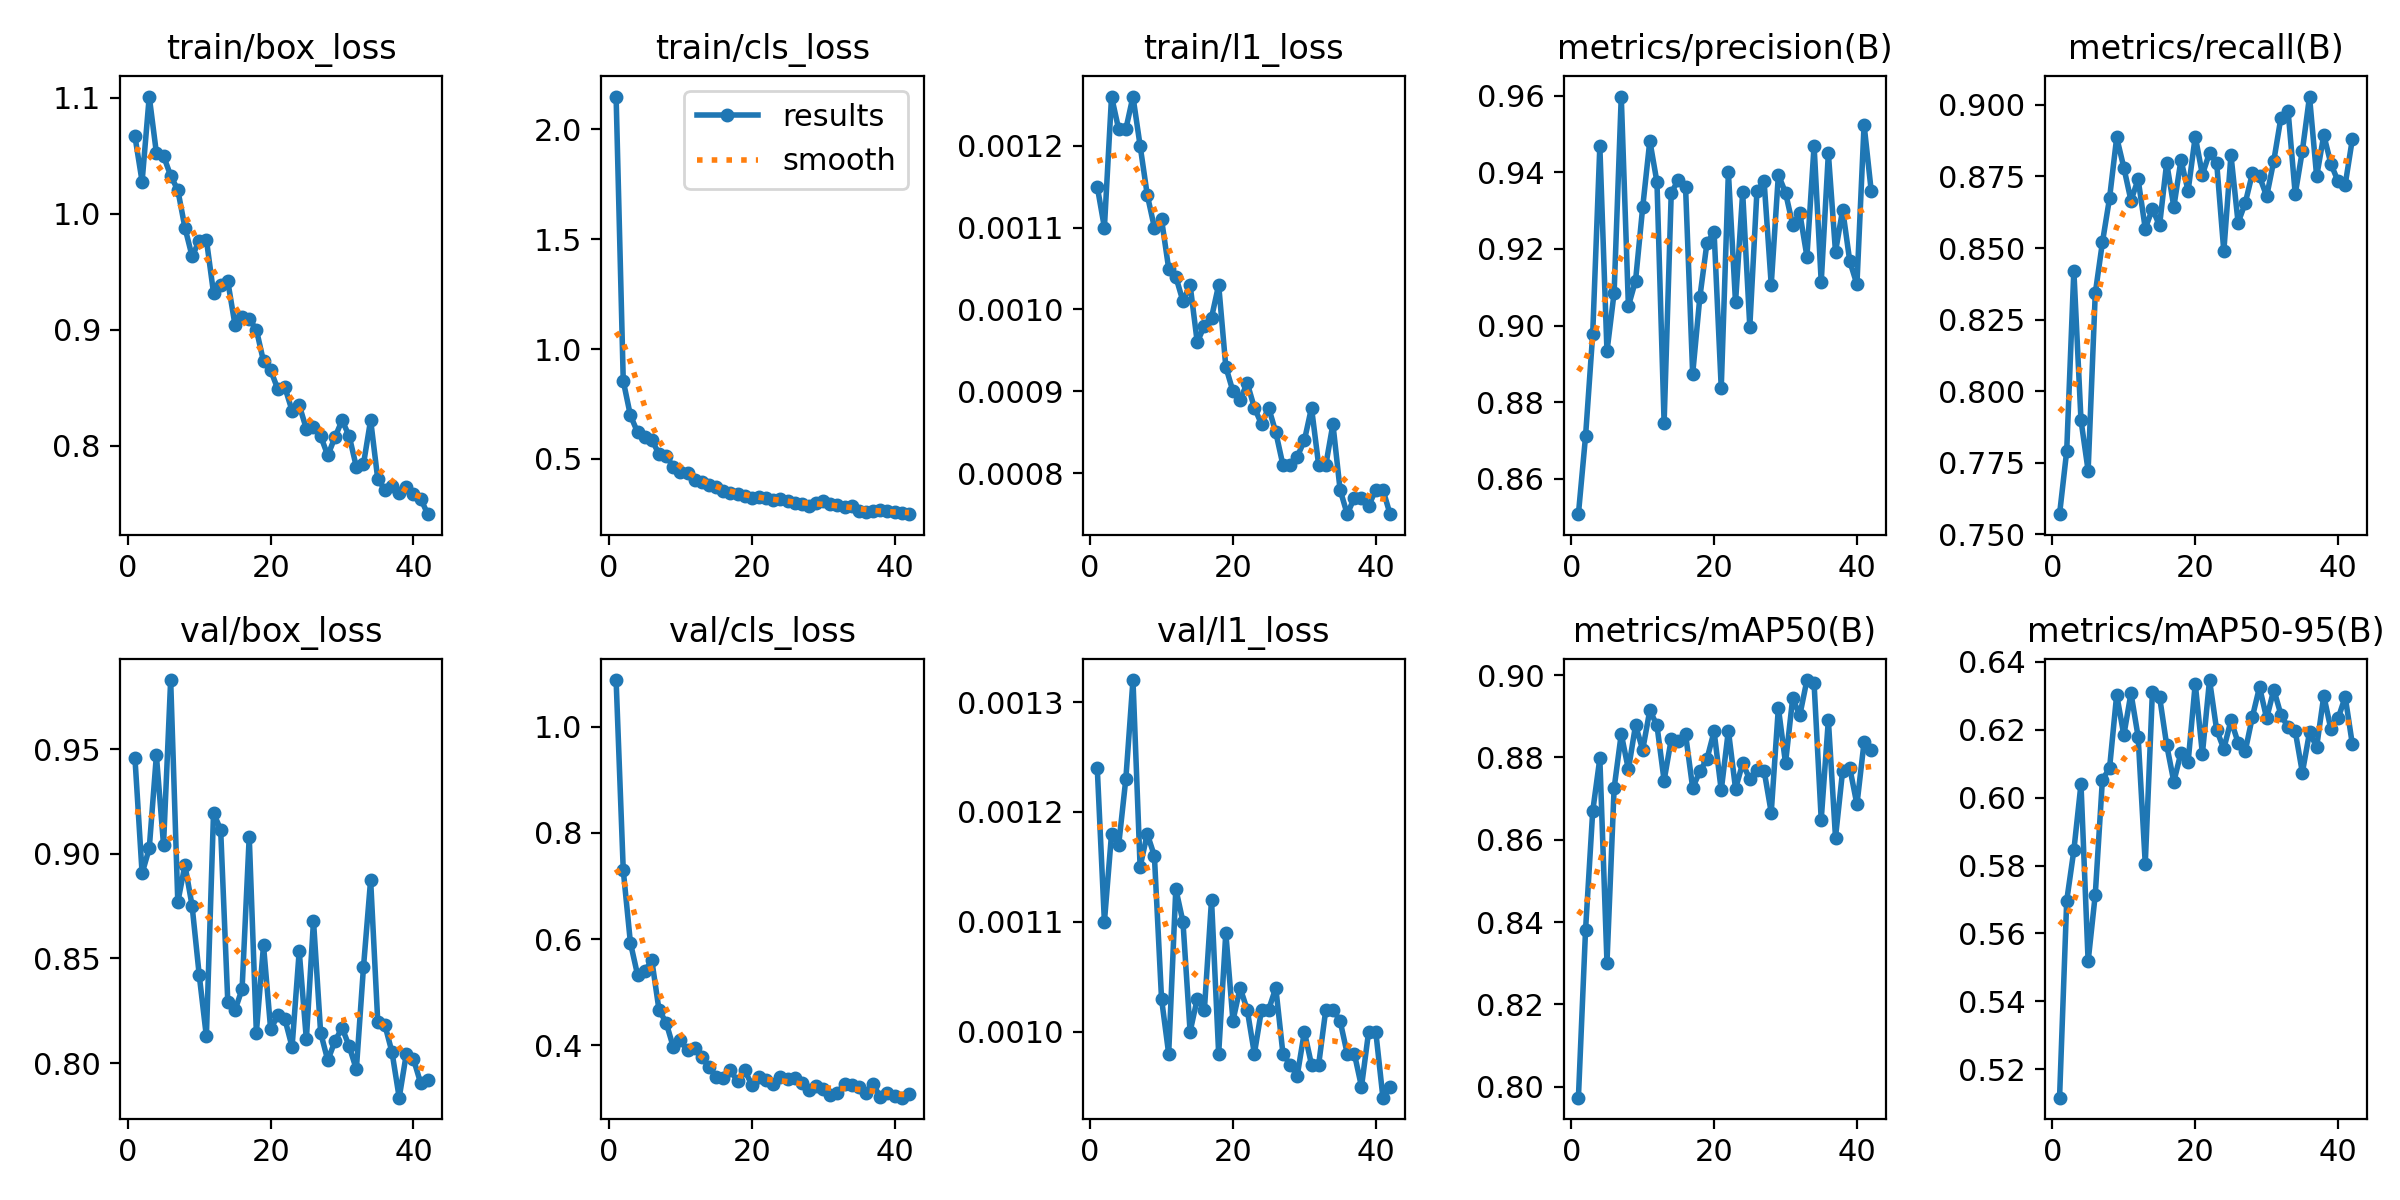

Ground truth: val_batch0_labels.jpg


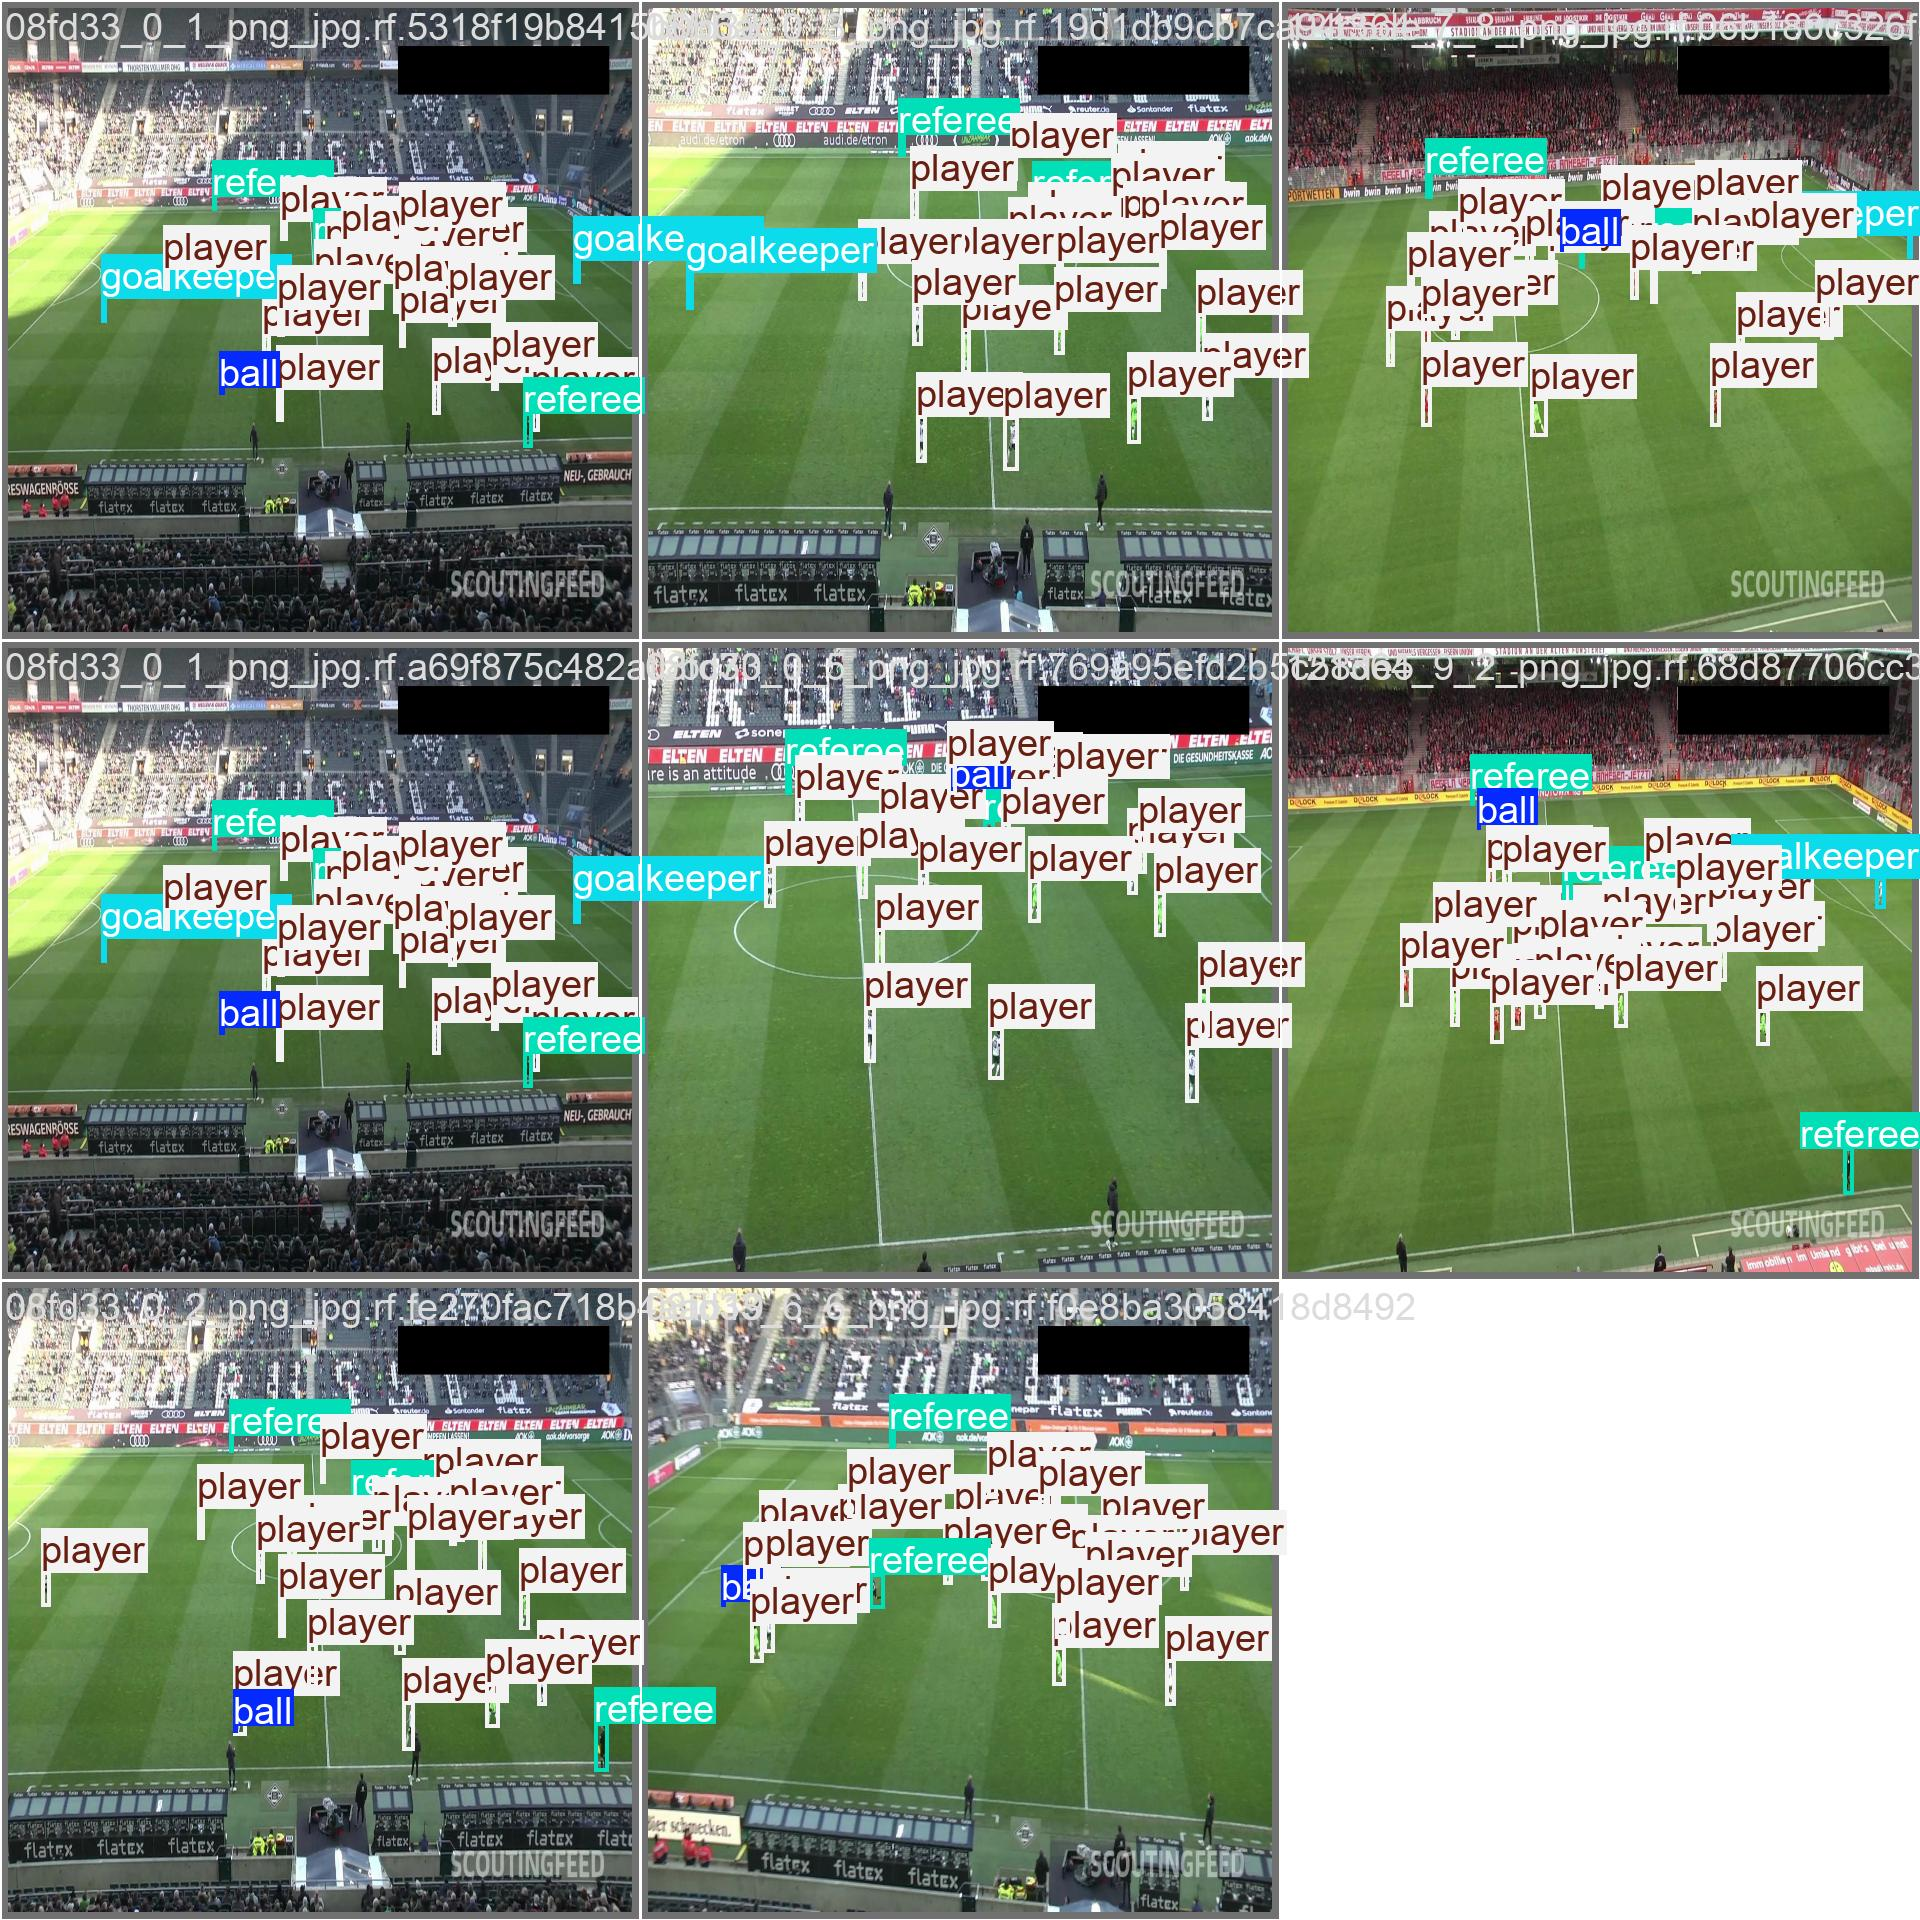

Predictions:  val_batch0_pred.jpg


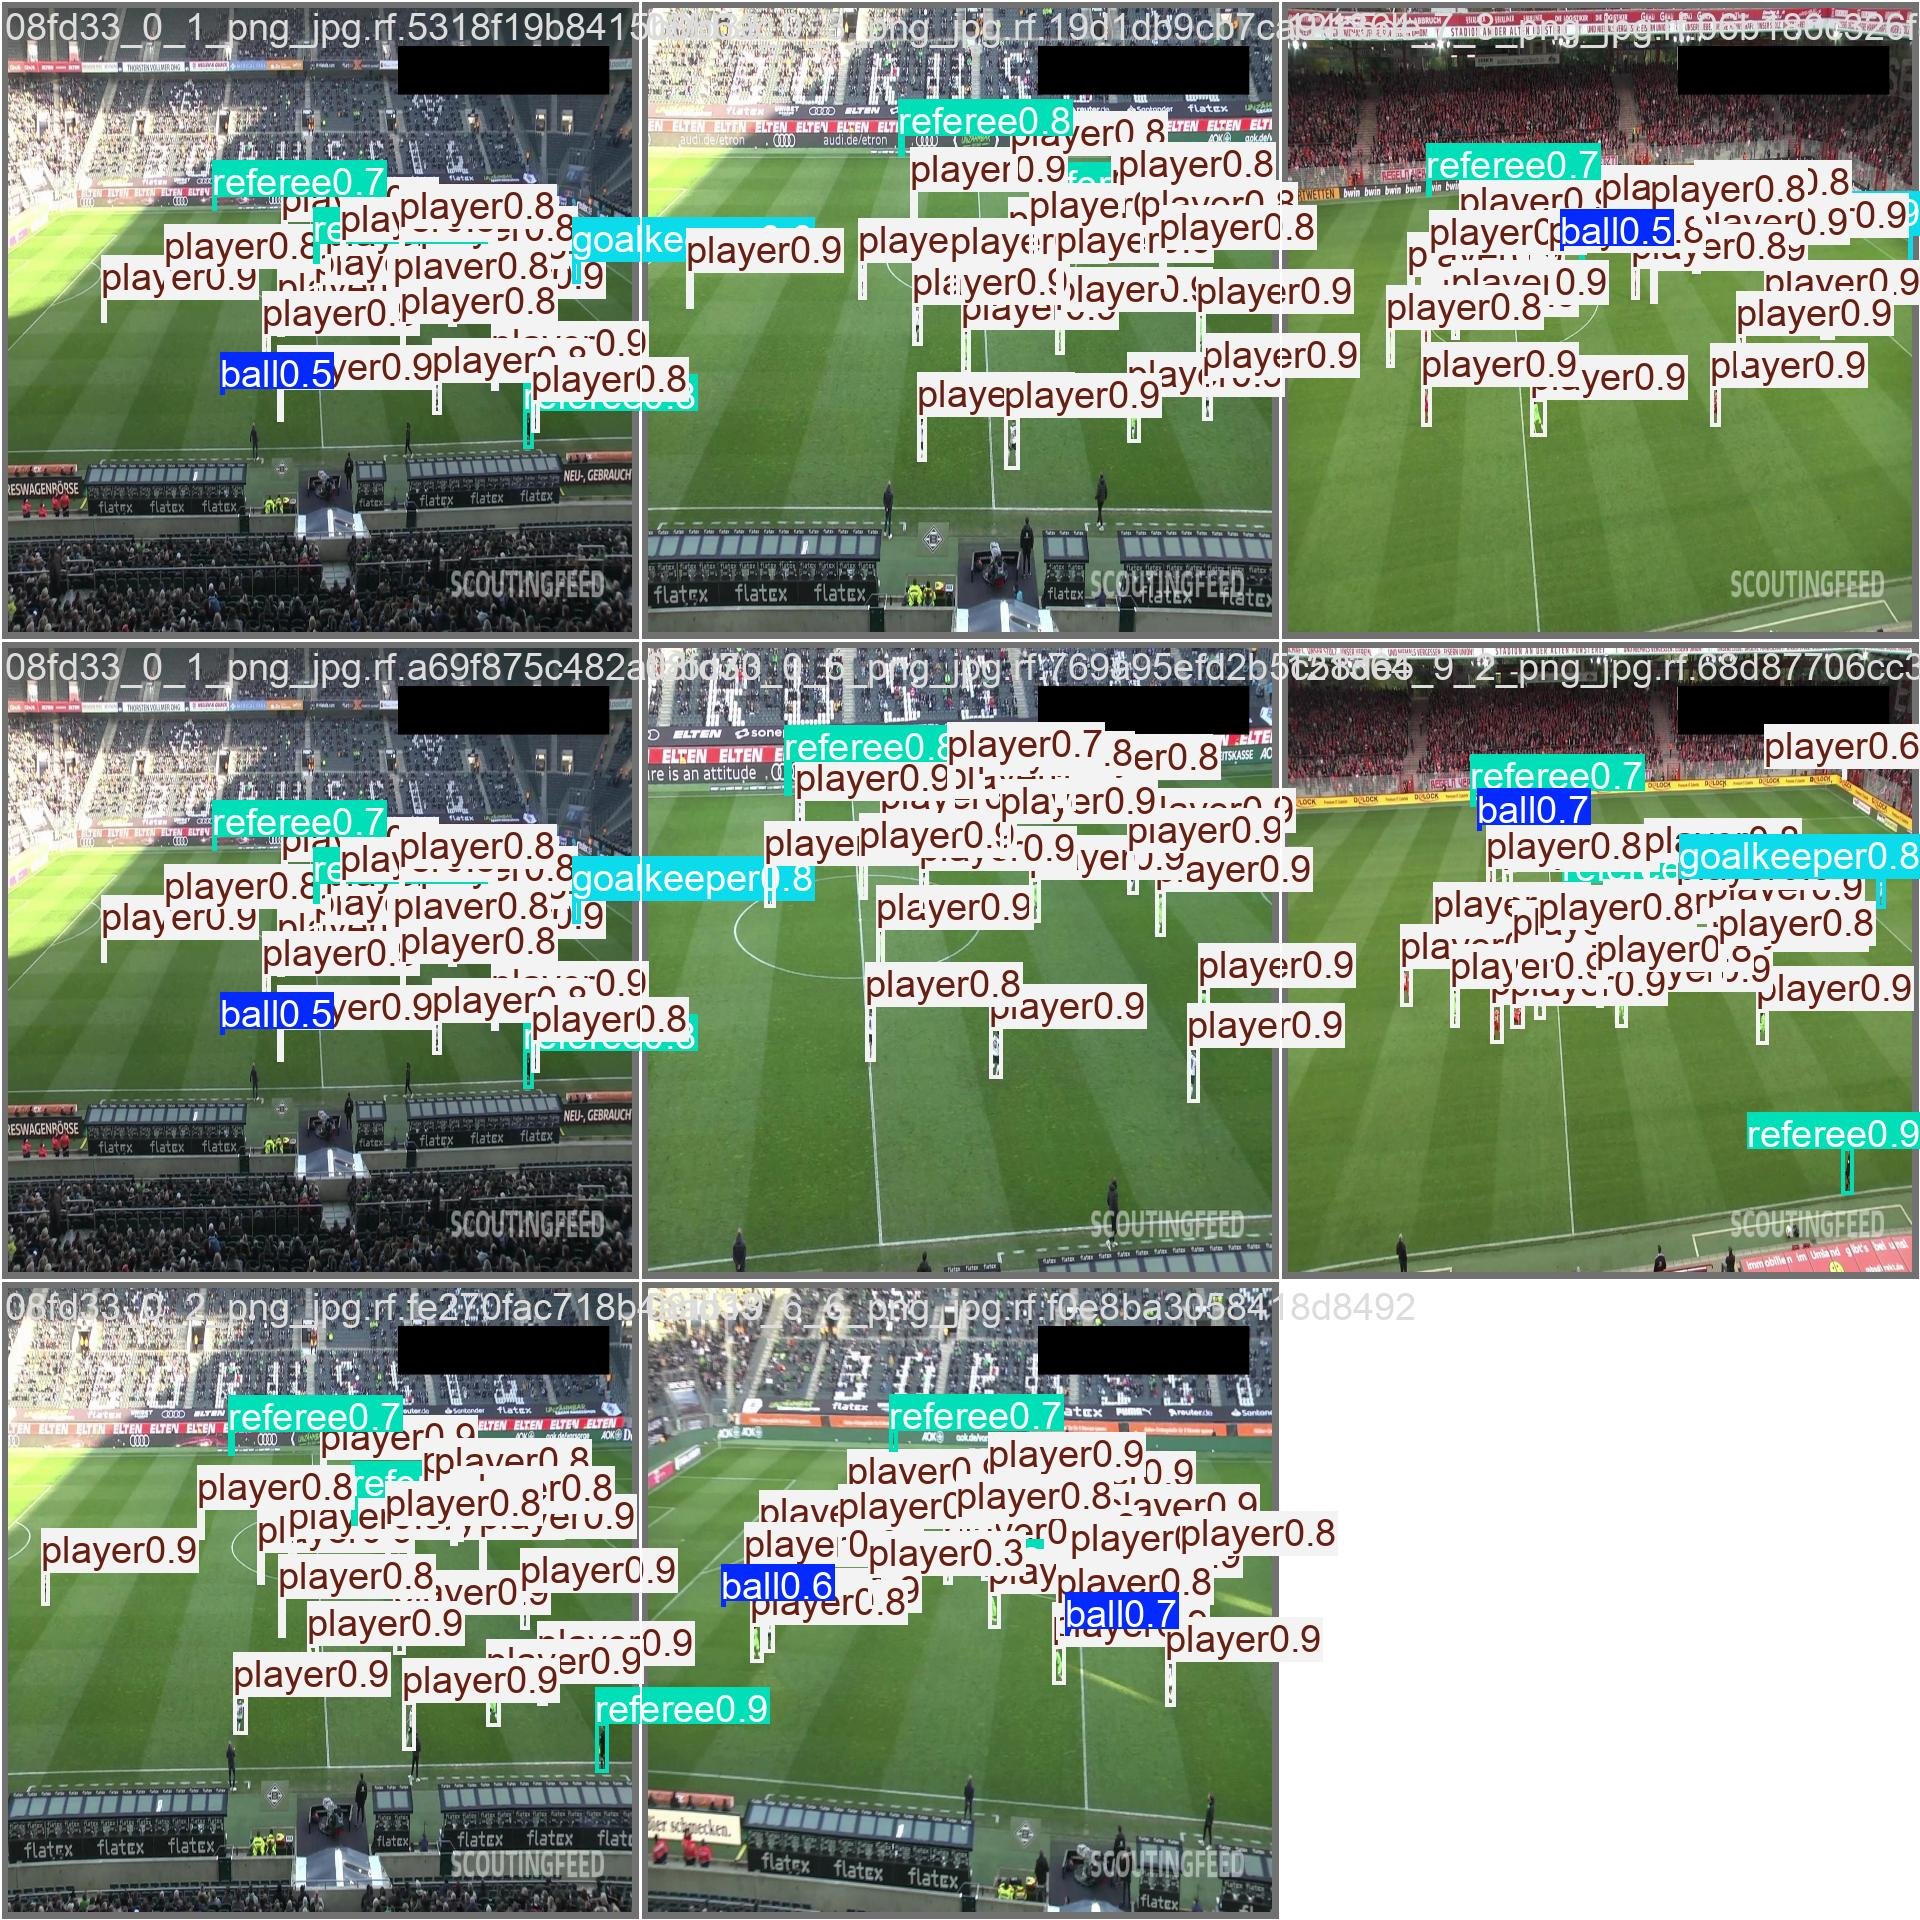

Ground truth: val_batch1_labels.jpg


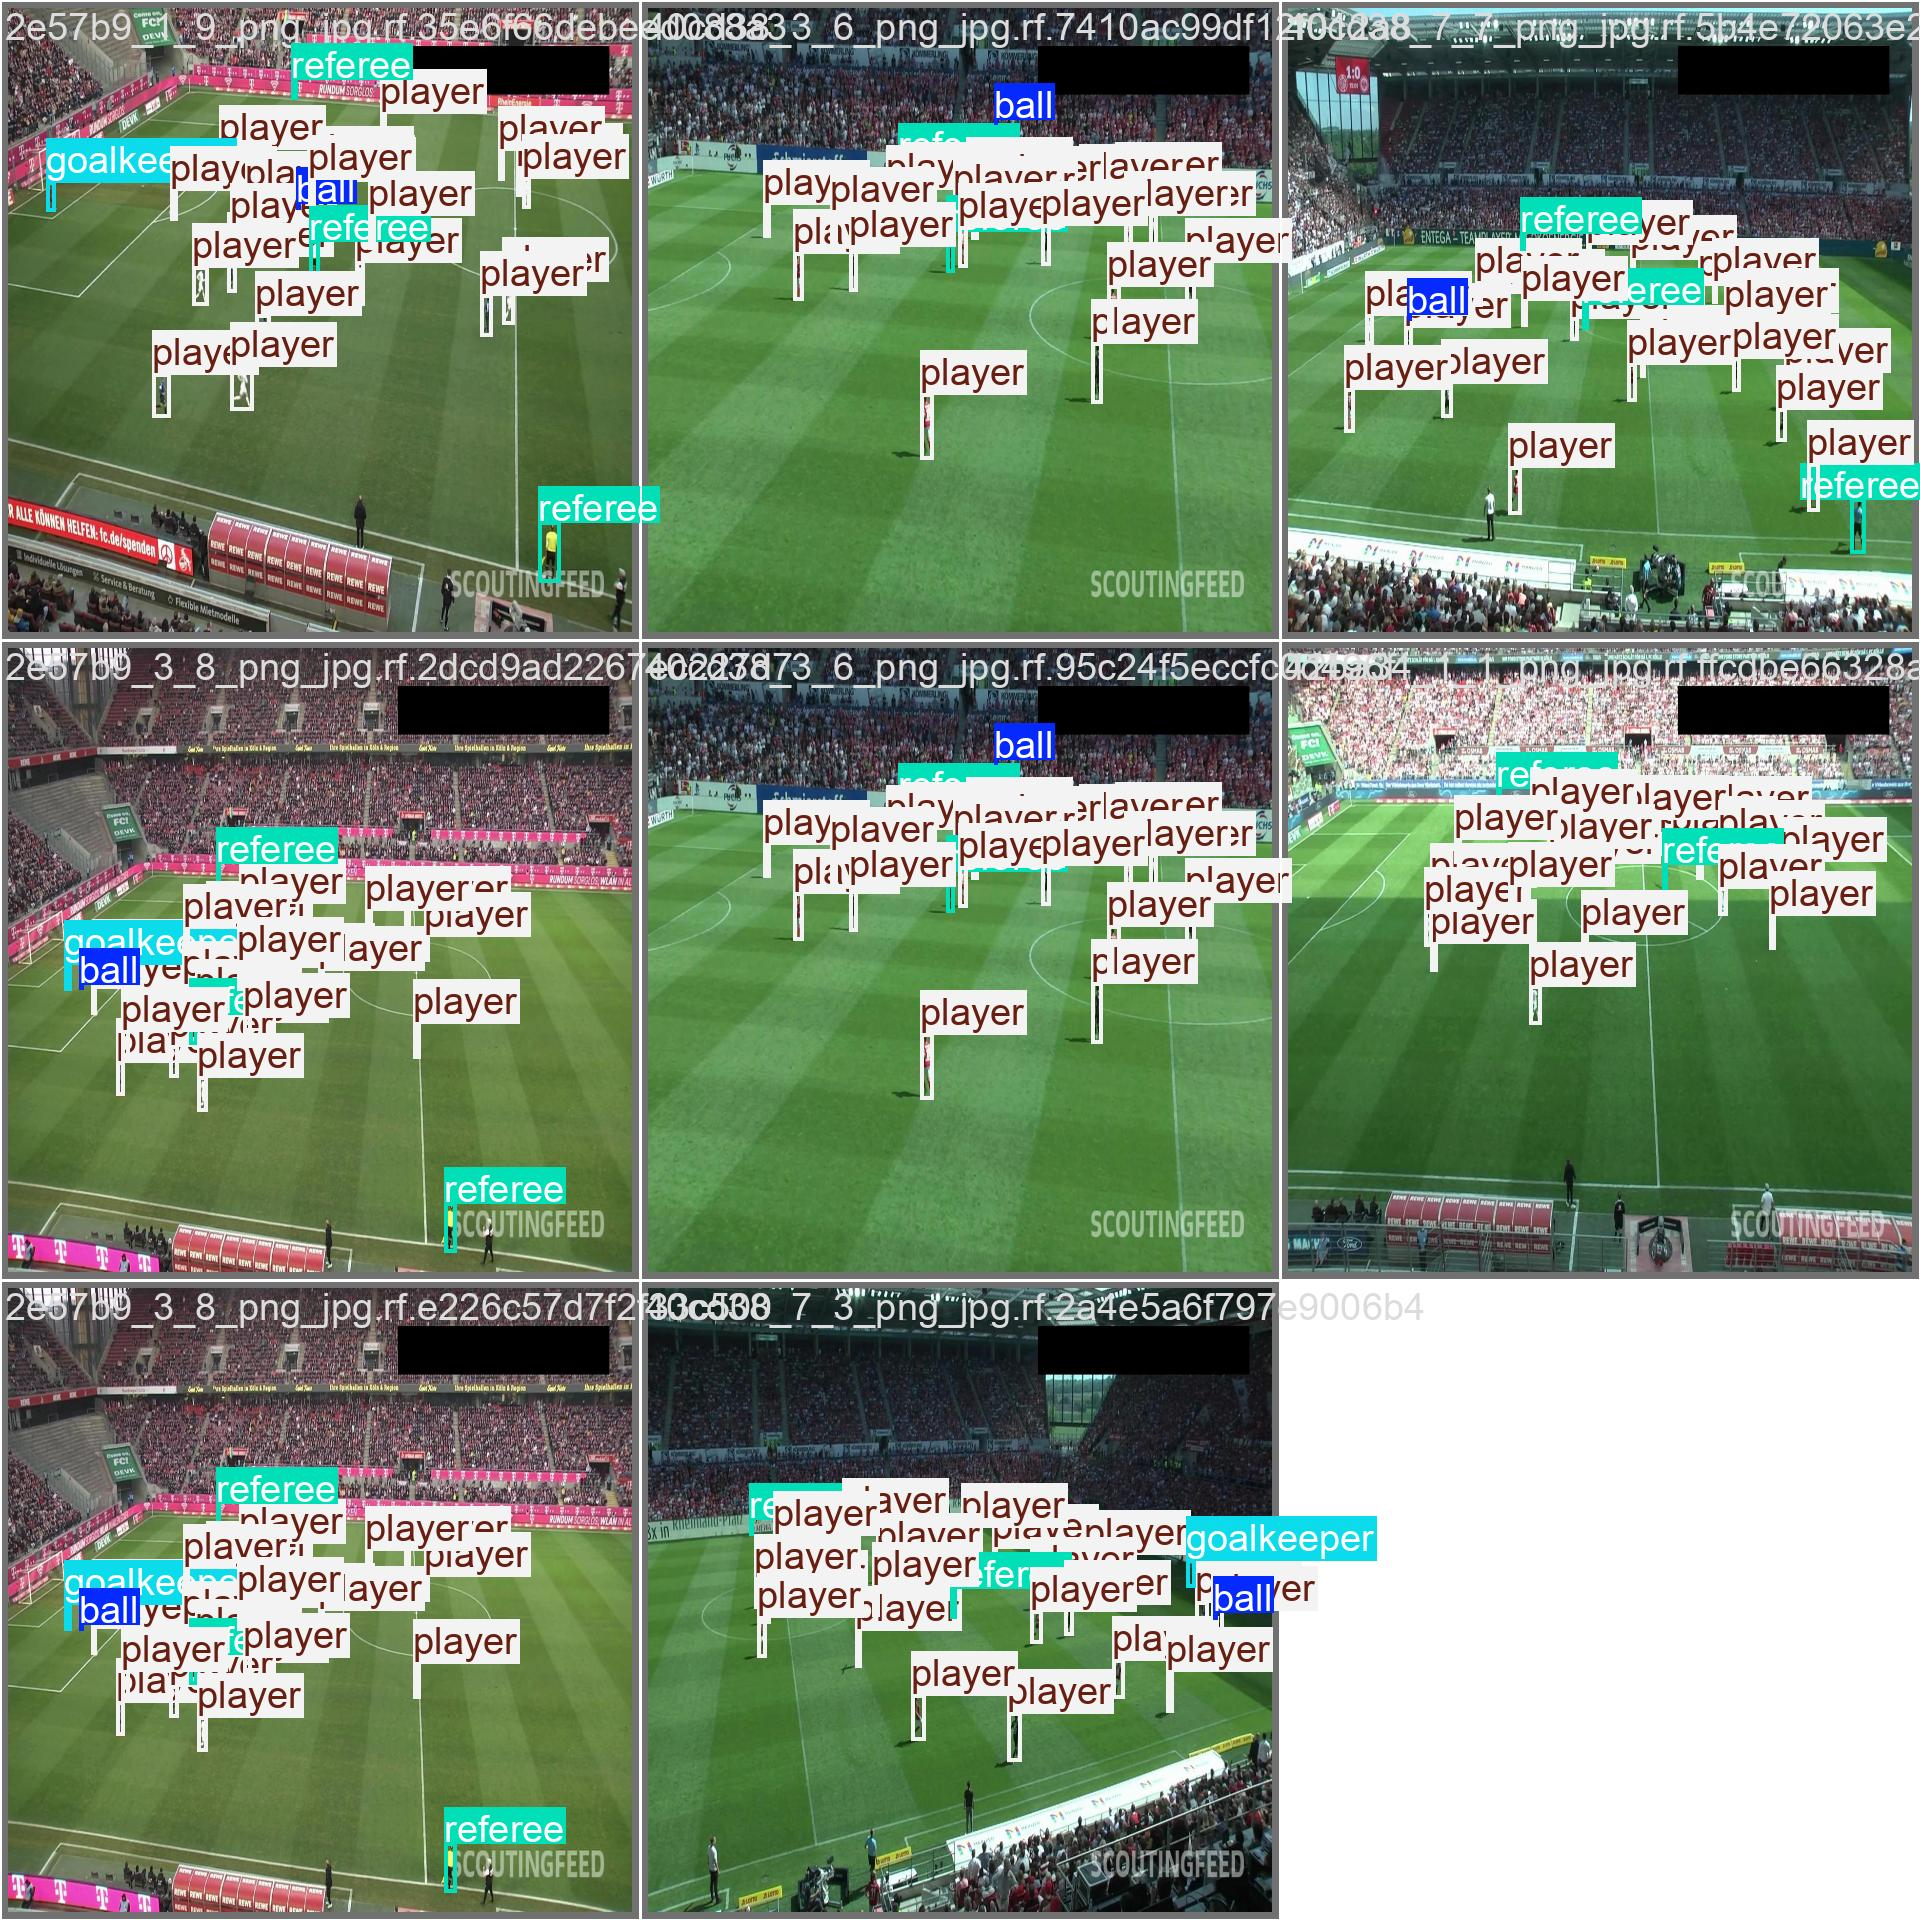

Predictions:  val_batch1_pred.jpg


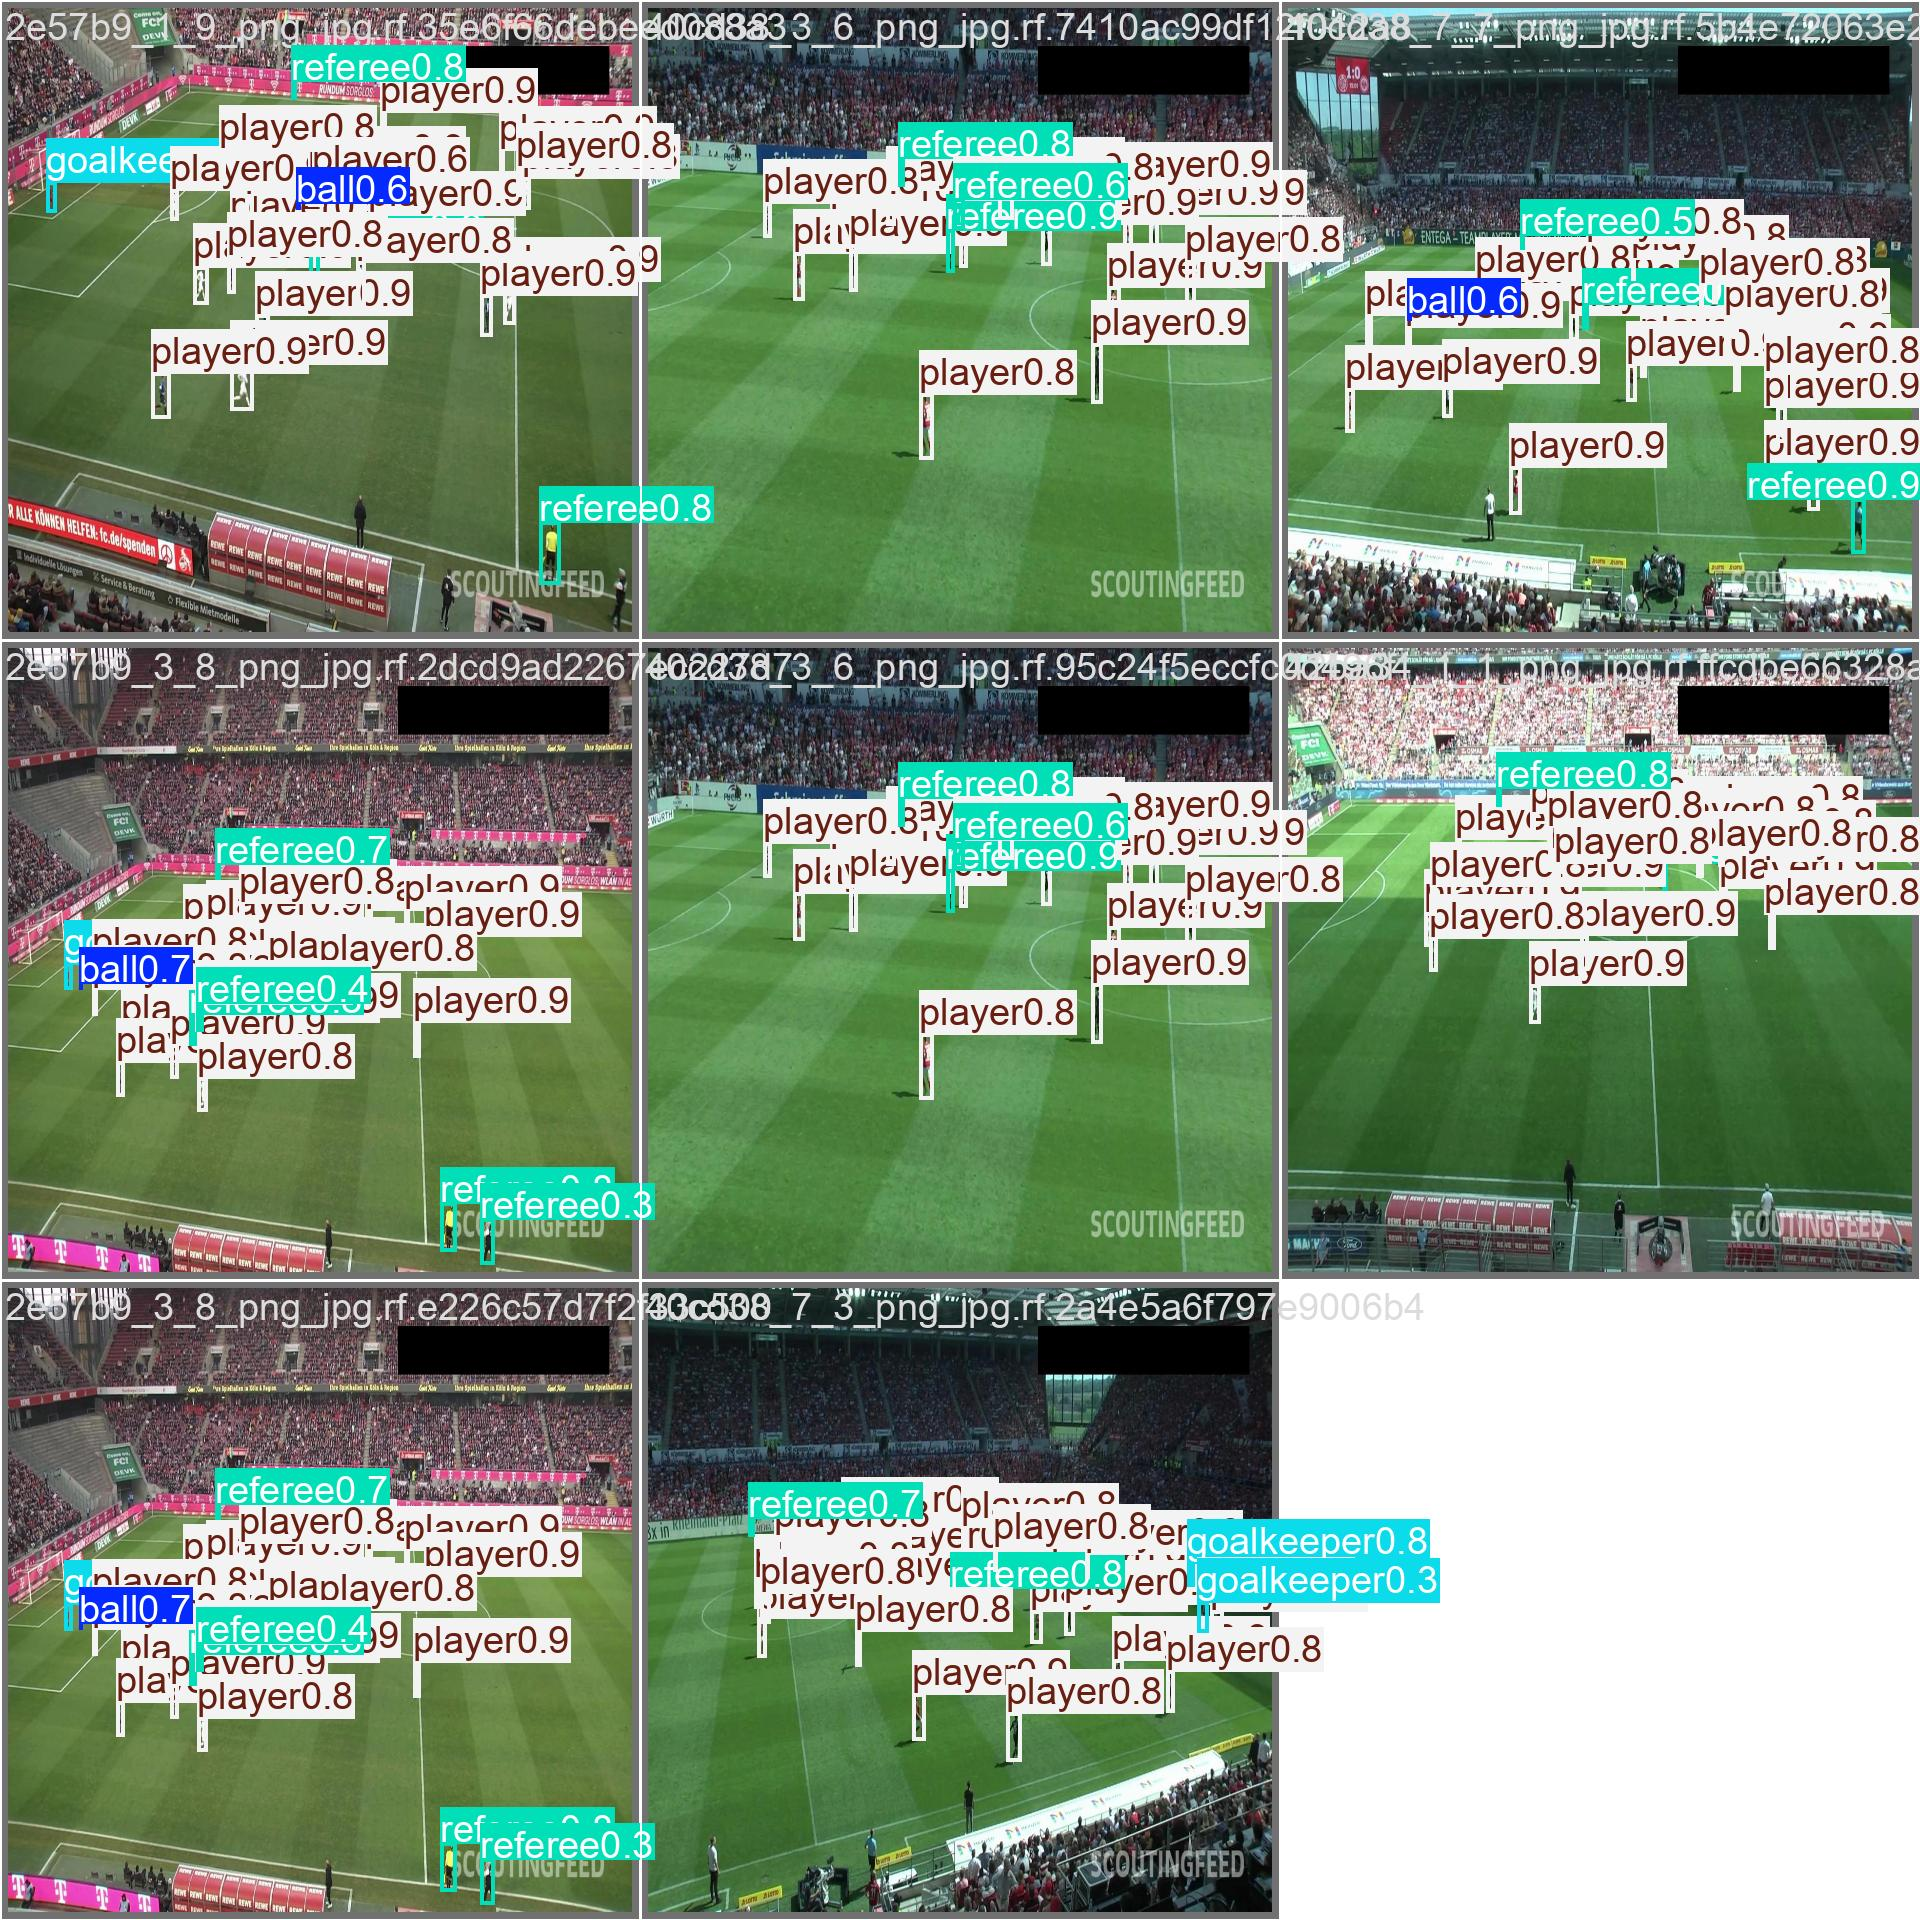

In [24]:
# Training curves (loss/mAP over epochs) and a batch of validation predictions vs. ground truth,
# saved during model.train() into RUN_DIR
train_plots = ["results.png"]
for plot_name in train_plots:
    plot_path = os.path.join(RUN_DIR, plot_name)
    if os.path.exists(plot_path):
        print(plot_name)
        display(IPyImage(filename=plot_path, width=900))

# val_batch*_labels.jpg = ground truth, val_batch*_pred.jpg = model predictions, same batch/layout
gt_batches = sorted(glob.glob(os.path.join(RUN_DIR, "val_batch*_labels.jpg")))[:2]
pred_batches = sorted(glob.glob(os.path.join(RUN_DIR, "val_batch*_pred.jpg")))[:2]

for gt_path, pred_path in zip(gt_batches, pred_batches):
    print("Ground truth:", os.path.basename(gt_path))
    display(IPyImage(filename=gt_path, width=900))
    print("Predictions: ", os.path.basename(pred_path))
    display(IPyImage(filename=pred_path, width=900))


## 5. Inference sanity check on unseen images

Run the fine-tuned model on a handful of held-out test-split images and save the annotated outputs - a quick visual check before wiring the model into the tracking pipeline.



0: 1280x1280 1 ball, 20 players, 3 referees, 107.6ms
1: 1280x1280 1 ball, 20 players, 1 referee, 107.6ms
2: 1280x1280 1 ball, 1 goalkeeper, 21 players, 3 referees, 107.6ms
3: 1280x1280 22 players, 2 referees, 107.6ms
4: 1280x1280 1 ball, 1 goalkeeper, 21 players, 3 referees, 107.6ms
5: 1280x1280 1 ball, 20 players, 3 referees, 107.6ms
Speed: 4.4ms preprocess, 107.6ms inference, 1.0ms postprocess per image at shape (1, 3, 1280, 1280)
Results saved to /kaggle/working/inference_samples


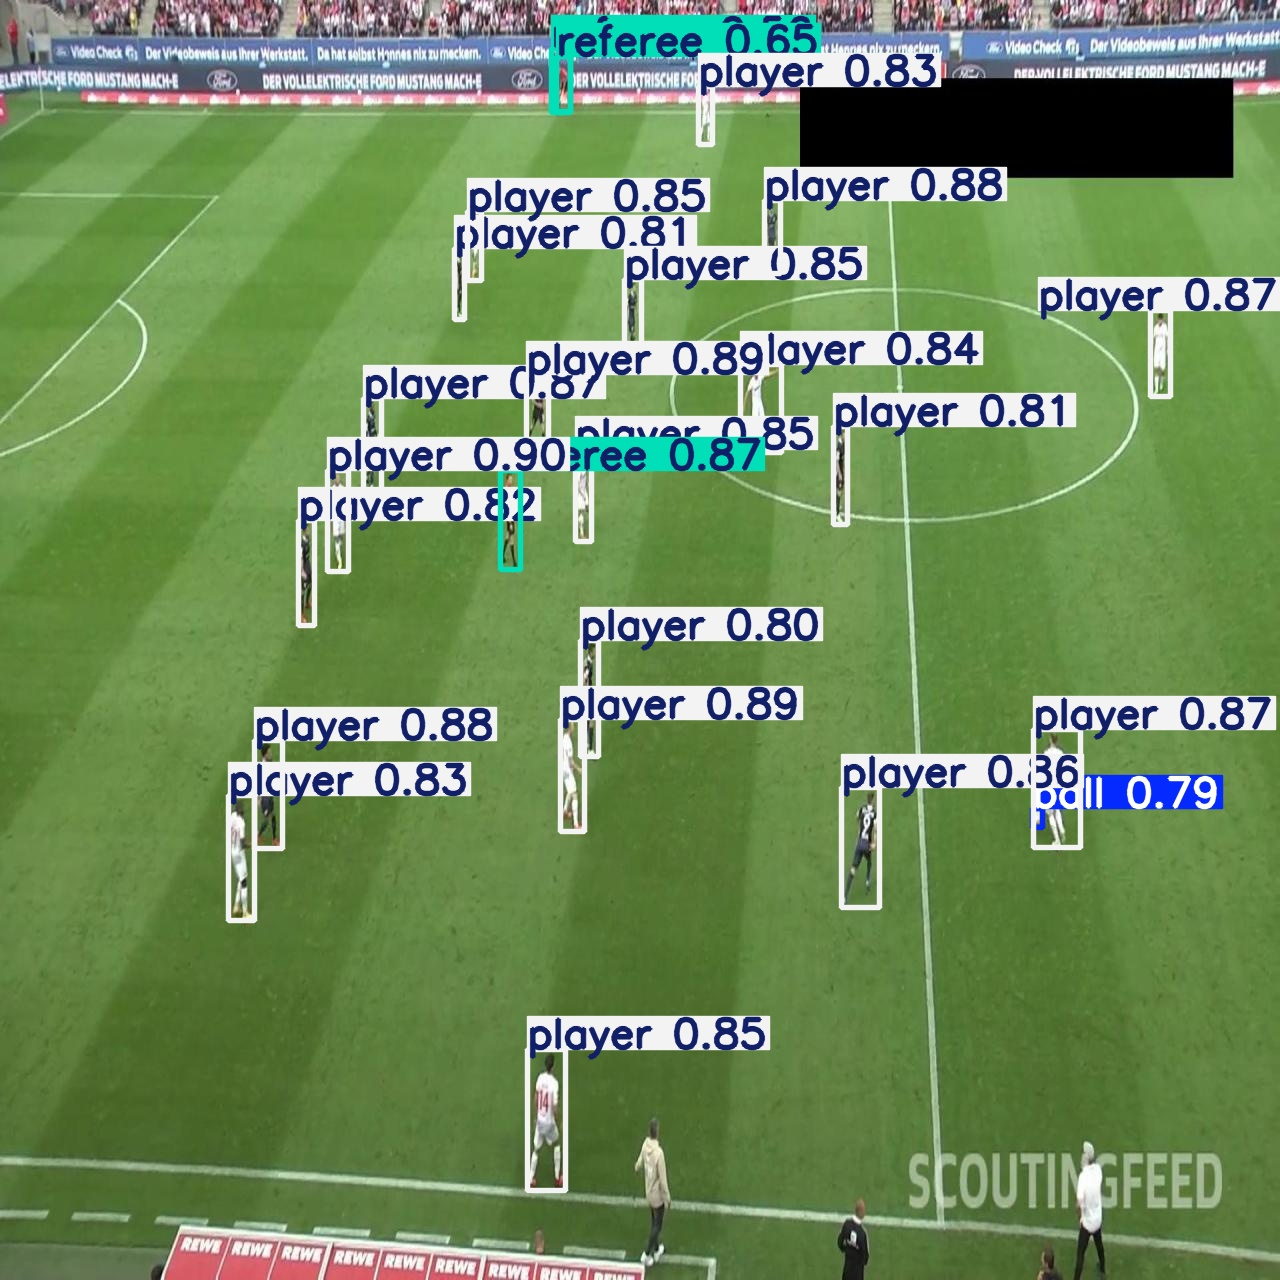

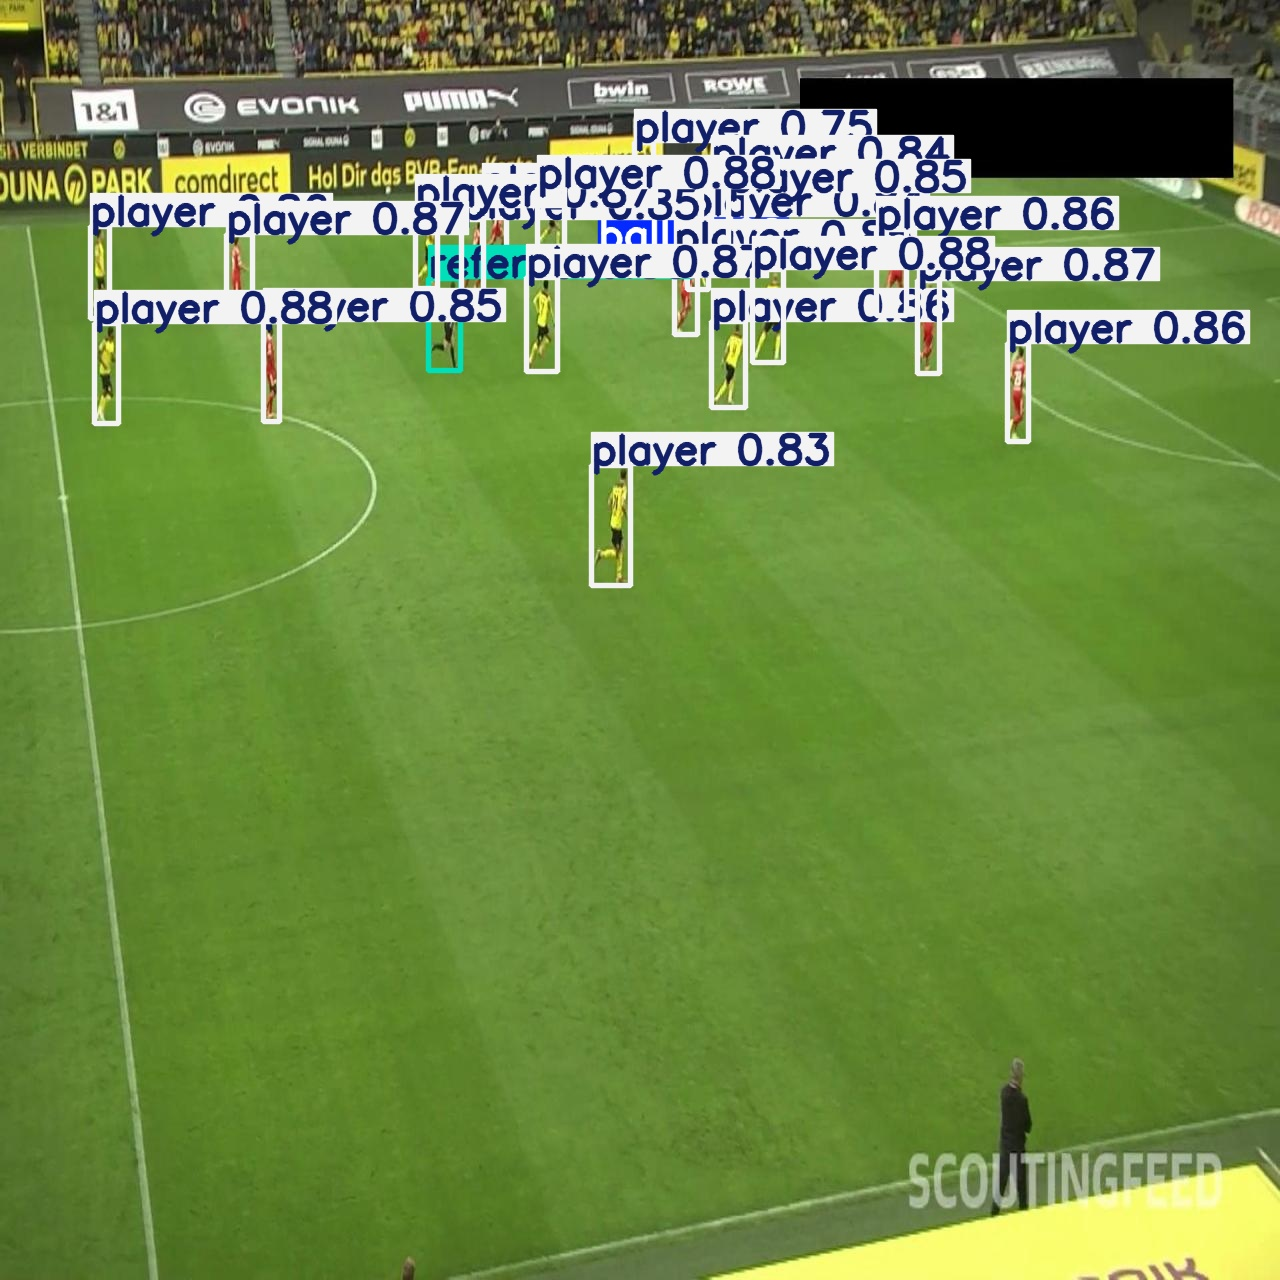

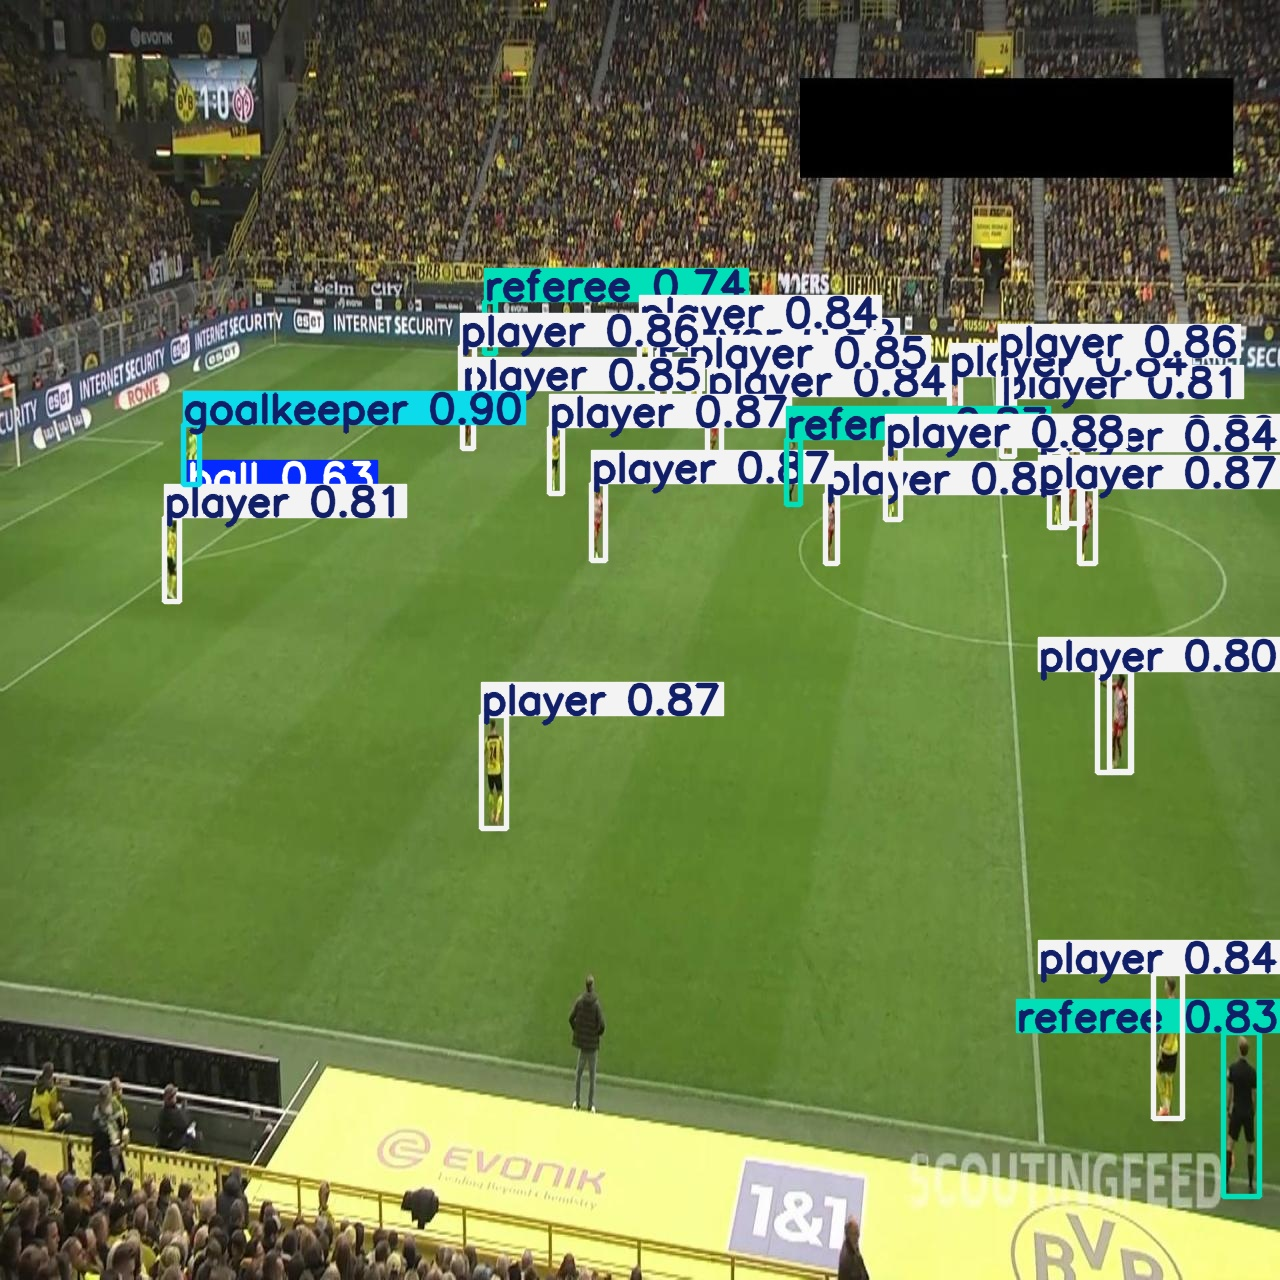

Annotated inference images saved to: /kaggle/working/inference_samples


In [25]:
best_weights_path = os.path.join(RUN_DIR, "weights", "best.pt")
inference_model = YOLO(best_weights_path)

test_img_dir = data_cfg.get("test", data_cfg["val"])
test_imgs = glob.glob(os.path.join(test_img_dir, "*.jpg"))[:6]

INFERENCE_OUT_DIR = os.path.join(WORK_DIR, "inference_samples")
os.makedirs(INFERENCE_OUT_DIR, exist_ok=True)

pred_results = inference_model.predict(
    source=test_imgs,
    imgsz=IMG_SIZE,
    conf=0.25,
    save=True,
    project=WORK_DIR,
    name="inference_samples",
    exist_ok=True,
)

for r in pred_results[:3]:
    display(IPyImage(filename=r.save_dir + "/" + os.path.basename(r.path), width=700))

print(f"Annotated inference images saved to: {os.path.join(WORK_DIR, 'inference_samples')}")


## 6. Save the model (and evaluation artifacts)

Bundles the trained weights + every evaluation plot/CSV into one zip so we can pull the whole thing straight into the tracking / team-classification / homography stages later, without retraining.


In [26]:
import shutil

EXPORT_DIR = os.path.join(WORK_DIR, "football_yolo26m_export")
os.makedirs(EXPORT_DIR, exist_ok=True)

# Weights
shutil.copy(best_weights_path, os.path.join(EXPORT_DIR, "football_players_yolo26m_best.pt"))
shutil.copy(os.path.join(RUN_DIR, "weights", "last.pt"), os.path.join(EXPORT_DIR, "football_players_yolo26m_last.pt"))

# Evaluation artifacts
eval_export_dir = os.path.join(EXPORT_DIR, "evaluation")
os.makedirs(eval_export_dir, exist_ok=True)
for plot_name in eval_plots + train_plots:
    src = os.path.join(EVAL_DIR, plot_name)
    if not os.path.exists(src):
        src = os.path.join(RUN_DIR, plot_name)
    if os.path.exists(src):
        shutil.copy(src, eval_export_dir)
if os.path.exists(metrics_csv_path):
    shutil.copy(metrics_csv_path, eval_export_dir)

# data.yaml, so class names/order are never ambiguous when reloading the model later
shutil.copy(data_yaml_path, os.path.join(EXPORT_DIR, "data.yaml"))

zip_path = shutil.make_archive(EXPORT_DIR, "zip", EXPORT_DIR)
print(f"Everything bundled at: {zip_path}")


Everything bundled at: /kaggle/working/football_yolo26m_export.zip


In [27]:
# Platform-specific persistence:
# - Colab: mount Drive and copy the zip there so it survives runtime resets, or trigger a direct download
# - Kaggle: anything written under /kaggle/working is automatically kept as the notebook's Output after you
#   commit/save the notebook, so the zip built above is already in the right place

if PLATFORM == "colab":
    from google.colab import drive, files
    drive.mount("/content/drive")
    drive_target = "/content/drive/MyDrive/football_yolo26m_export.zip"
    shutil.copy(zip_path, drive_target)
    print(f"Copied to Google Drive: {drive_target}")
    # Uncomment to also trigger a browser download:
    # files.download(zip_path)
elif PLATFORM == "kaggle":
    print("Running on Kaggle - files under /kaggle/working are saved automatically as this notebook's Output")
    print(f"Zip location: {zip_path}")
else:
    print(f"Zip location: {zip_path}")


Running on Kaggle - files under /kaggle/working are saved automatically as this notebook's Output
Zip location: /kaggle/working/football_yolo26m_export.zip


## Next steps

`football_players_yolo26m_best.pt` (+ `data.yaml` for class names) is now ready to drop into the rest of the pipeline:

```python
from ultralytics import YOLO
model = YOLO("football_players_yolo26m_best.pt")
```

Reload it with `supervision`'s ByteTrack for player/ball tracking on a downloaded YouTube clip, then feed the tracked player crops into the SigLIP + UMAP + KMeans team-classification stage, and separately train/apply the pitch-keypoint model for the homography + 2D radar projection.
